<a href="https://colab.research.google.com/github/Shritant/Inspirit_AIColabs/blob/main/Cern_Electron_Collision_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
fedesoriano_cern_electron_collision_data_path = kagglehub.dataset_download('fedesoriano/cern-electron-collision-data')

print('Data source import complete.')


100%|██████████| 6.25M/6.25M [00:00<00:00, 105MB/s]

Extracting files...


Data source import complete.


<div style="border-radius:40px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:150%; text-align:left">
    
<h3 align="center"><font color='#9999' size=150%>ELECTRON COLLISION</font></h3>

<h4 align="left"><font color='#9999' size=5%>To Do :</font></h4>
    
<li> Cleaning dataset for regression</li>
    
<li> Some analysis and statistics</li>
    
<li> ML, ANN, CNN</li>

<h3 align="left"><font color='#9999' size=5%>ABOUT DATASET :</font></h3>
    
<p>This dataset contains 100k dielectron events in the invariant mass range 2-110 GeV for use in outreach and education. These data were selected for use in education and outreach and contain a subset of the total event information. The selection criteria may be different from that used in CMS physics results.</p>
     
<p>You can go <a href="https://home.cern/">Cern</a>.</p>
<p>For more information about Electron Collision <a href="https://en.wikipedia.org/wiki/Electron%E2%80%93positron_annihilation">Wikipedia</a>.</p>    
<div style="border-radius: 10px; overflow: hidden; text-align: left;">
    <a href="https://home.cern/"><img src="https://cds.cern.ch/images/CMS-PHO-EVENTS-2020-026-3/file?size=large"
    alt="Cern" width="1000"></a></div>  
<div style="border-radius: 10px; overflow: hidden; text-align: right;">
    <a href="https://en.wikipedia.org/wiki/Electron%E2%80%93positron_annihilation"><img          src="https://astroengine.files.wordpress.com/2012/07/intro.jpg?w=840"
    alt="Electron Collision" width="1000"></a></div>   
<div style="border-radius: 10px; overflow: hidden; text-align: left;">
    <a href="https://en.wikipedia.org/wiki/Electron%E2%80%93positron_annihilation"><img src="https://www.researchgate.net/publication/282710834/figure/fig4/AS:614292609040401@1523470179353/Color-online-Illustration-of-laser-induced-electron-collision-in-sequential-double.png"
    alt="Laser-induced Electron Collision" width="1000"></a></div>   
<div style="border-radius: 10px; overflow: hidden; text-align: right;">
    <a href="https://en.wikipedia.org/wiki/Electron%E2%80%93positron_annihilation"><img src="https://pub.mdpi-res.com/applsci/applsci-10-01418/article_deploy/html/images/applsci-10-01418-g001.png?1583504613"
    alt="Electron Collision Illustration" width="1000"></a></div>
</div>


# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> LINKS </div>

#### **Name :** Mesut Suhan Şişman

<div style="text-align: left;">
    <table>
        <tr>
            <th><b>Links</b></th>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>GitHub</td>
            <td><a href="https://github.com/Mesutssmn"><img src="https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github" alt="GitHub"/></a></td>
        </tr>
        <tr>
            <td>LinkedIn</td>
            <td><a href="https://www.linkedin.com/in/mesut-suhan-sisman/"><img src="https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin" alt="LinkedIn"/></a></td>
        </tr>
        <tr>
        </tr>
        <tr>
    </table>

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> IMPORTS </div>

In [ ]:
# Base Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data Analysis Libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import MinMaxScaler,StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer, classification_report,confusion_matrix
import scipy.stats as stats
from scipy.stats import shapiro, levene, kruskal

# Machine Learning Libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 55)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> LOADING DATA </div>

In [ ]:
df_ = pd.read_csv(fedesoriano_cern_electron_collision_data_path + "/dielectron.csv")

In [ ]:
df = df_.copy()
df.head()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,-1,8.948
1,147115,366704169,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,-1,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893
2,147115,367112316,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388
3,147115,366952149,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,-1,3.729
4,147115,366523212,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,-1,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,-1,2.747


In [ ]:
np.mean(df["M"])

np.float64(30.019521281689435)

In [ ]:
np.std(df["M"])

25.255720271837948

In [ ]:
np.sqrt(np.mean((np.mean(df["M"])-df["M"])**2))

np.float64(25.25572027183806)

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> FEATURES </div>

1) ***Run*** : The run number of the event.
    
2) ***Event*** : The event number.
    
3) ***E1, E2*** : The total energy of the electron (GeV) for electrons 1 and 2.
    
4) ***px1, py1, pz1, px2, py2, pz2***: The components of the momemtum of the electron 1 and 2 (GeV).
    
5) ***pt1, pt2***: The transverse momentum of the electron 1 and 2 (GeV).
    
6) ***eta1, eta2***: The pseudorapidity of the electron 1 and 2.
    
7) ***phi1, phi2***: The phi angle of the electron 1 and 2 (rad).
    
8) ***Q1, Q2***: The charge of the electron 1 and 2.
    
9) ***M***: The invariant mass of two electrons (GeV).

Cite as: McCauley, Thomas; (2014). https://opendata.cern.ch/record/304
    
Dataset: https://www.kaggle.com/datasets/fedesoriano/cern-electron-collision-data

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> DATA INFORMATION </div>

In [ ]:
df["Event"].value_counts()

,count
Event,
439950319,3
440012942,3
407103633,2
407076179,2
406690266,2
...,...
533379552,1
532994296,1
533628462,1


In [ ]:
df.drop("Event", axis = 1, inplace = True)

In [ ]:
df.Q1.value_counts()

,count
Q1,
-1,50274
1,49726


In [ ]:
df.Q2.value_counts()

,count
Q2,
-1,50211
1,49789


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   E1      100000 non-null  float64
 2   px1     100000 non-null  float64
 3   py1     100000 non-null  float64
 4   pz1     100000 non-null  float64
 5   pt1     100000 non-null  float64
 6   eta1    100000 non-null  float64
 7   phi1    100000 non-null  float64
 8   Q1      100000 non-null  int64  
 9   E2      100000 non-null  float64
 10  px2     100000 non-null  float64
 11  py2     100000 non-null  float64
 12  pz2     100000 non-null  float64
 13  pt2     100000 non-null  float64
 14  eta2    100000 non-null  float64
 15  phi2    100000 non-null  float64
 16  Q2      100000 non-null  int64  
 17  M       99915 non-null   float64
dtypes: float64(15), int64(3)
memory usage: 13.7 MB


In [ ]:
df.dropna(axis = 0, inplace = True)

In [ ]:
df.describe(percentiles = [0.05, 0.10, 0.20, 0.35, 0.50, 0.65, 0.70, 0.75, 0.85, 0.95]).T

,count,mean,std,min,5%,10%,20%,35%,50%,65%,70%,75%,85%,95%,max
Run,99915.000,147935.420,920.316,146511.000,146644.000,146644.000,146944.000,147754.000,147929.000,148031.000,149011.000,149011.000,149181.000,149181.000,149182.000
E1,99915.000,36.460,41.225,0.378,2.624,3.399,6.193,13.639,21.740,34.033,40.795,50.059,73.649,117.668,850.602
px1,99915.000,0.136,13.409,-250.587,-21.268,-15.359,-8.346,-2.380,0.142,2.562,3.708,5.719,12.135,21.405,134.539
py1,99915.000,0.183,13.475,-126.079,-21.336,-15.359,-8.392,-2.370,0.101,2.550,3.677,5.652,12.288,21.663,147.467
pz1,99915.000,-1.509,51.625,-840.987,-89.365,-58.845,-22.874,-7.092,-0.313,5.072,8.768,13.234,30.318,83.368,760.096
pt1,99915.000,14.418,12.391,0.220,2.079,2.410,3.188,5.710,12.973,17.096,18.503,20.026,25.201,39.188,265.578
eta1,99915.000,-0.064,1.463,-4.165,-2.312,-2.108,-1.601,-0.814,-0.061,0.667,0.915,1.145,1.751,2.241,2.623
phi1,99915.000,0.022,1.800,-3.142,-2.813,-2.486,-1.847,-0.874,0.035,0.970,1.271,1.563,2.187,2.816,3.141
Q1,99915.000,-0.005,1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,1.000,1.000,1.000,1.000,1.000,1.000
E2,99915.000,44.029,46.762,0.472,2.882,4.348,9.044,15.580,25.291,46.352,56.871,66.983,88.851,133.202,948.375


In [ ]:
def grab_col_names(dataframe, cat_th=15, car_th=20):

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 99915
Variables: 18
cat_cols: 3
num_cols: 15
cat_but_car: 0
num_but_cat: 3


In [ ]:
cat_cols, num_cols, cat_but_car

(['Run', 'Q1', 'Q2'],
 ['E1',
  'px1 ',
  'py1',
  'pz1',
  'pt1',
  'eta1',
  'phi1',
  'E2',
  'px2',
  'py2',
  'pz2',
  'pt2',
  'eta2',
  'phi2',
  'M'],
 [])

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> VISUALIZATIONS </div>

          Run  Ratio
Run                 
149181  18096 18.111
146644  12617 12.628
149011   9255  9.263
148031   8190  8.197
147926   7549  7.555
147929   6886  6.892
147754   6833  6.839
148029   6758  6.764
147114   6144  6.149
147115   5841  5.846
146944   5815  5.820
146511   3014  3.017
149182   2917  2.919


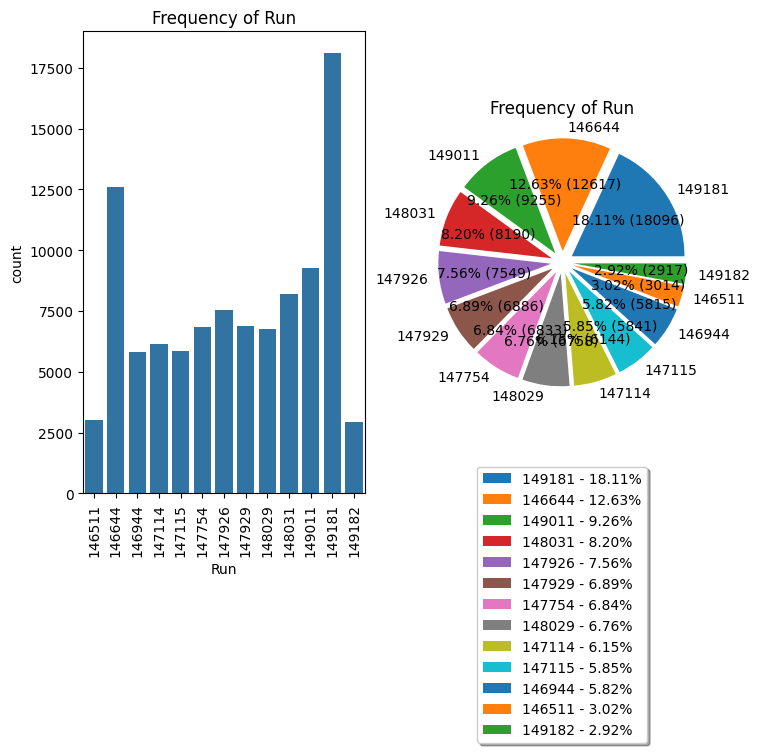

       Q1  Ratio
Q1              
-1  50232 50.275
 1  49683 49.725


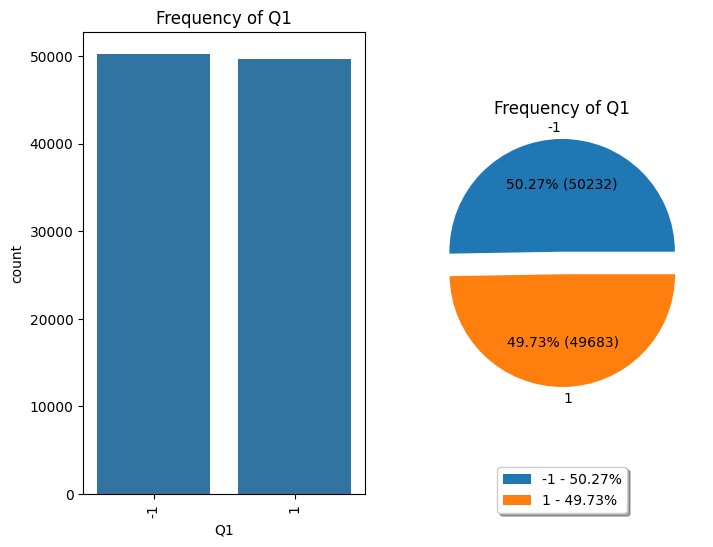

       Q2  Ratio
Q2              
-1  50169 50.212
 1  49746 49.788


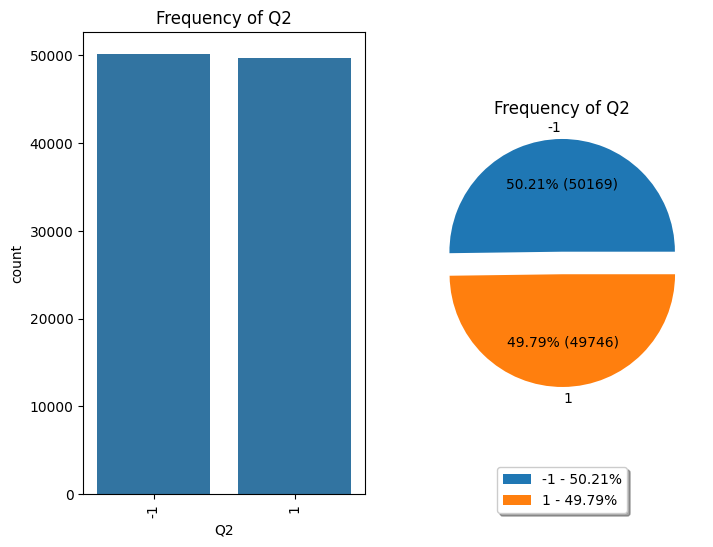

In [ ]:
def cat_summary(dataframe, col_name, plot=False, explode=None):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    # Countplot
    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(8, 6))
        plt.subplot(1, 2, 1)
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.title("Frequency of " + col_name)
        plt.xticks(rotation=90)
    # Pieplot
        plt.subplot(1, 2, 2)
        values = dataframe[col_name].value_counts()
        plt.pie(x=values, labels=values.index, autopct=lambda p: '{:.2f}% ({:.0f})'.format(p, p/100 * sum(values)), explode=explode)
        plt.title("Frequency of " + col_name)
        plt.legend(labels=['{} - {:.2f}%'.format(index, value/sum(values)*100) for index, value in zip(values.index, values)],
                   loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=1)
        plt.show(block=True)

for col in cat_cols:
    cat_summary(df, col, True, explode=[0.1] * df[col].nunique())

count   99915.000
mean       36.460
std        41.225
min         0.378
5%          2.624
10%         3.399
20%         6.193
30%        11.001
40%        16.133
50%        21.740
60%        28.717
70%        40.795
80%        61.163
90%        90.204
95%       117.668
99%       189.608
max       850.602
Name: E1, dtype: float64
Skewness: 2.51
Kurtosis: 12.34


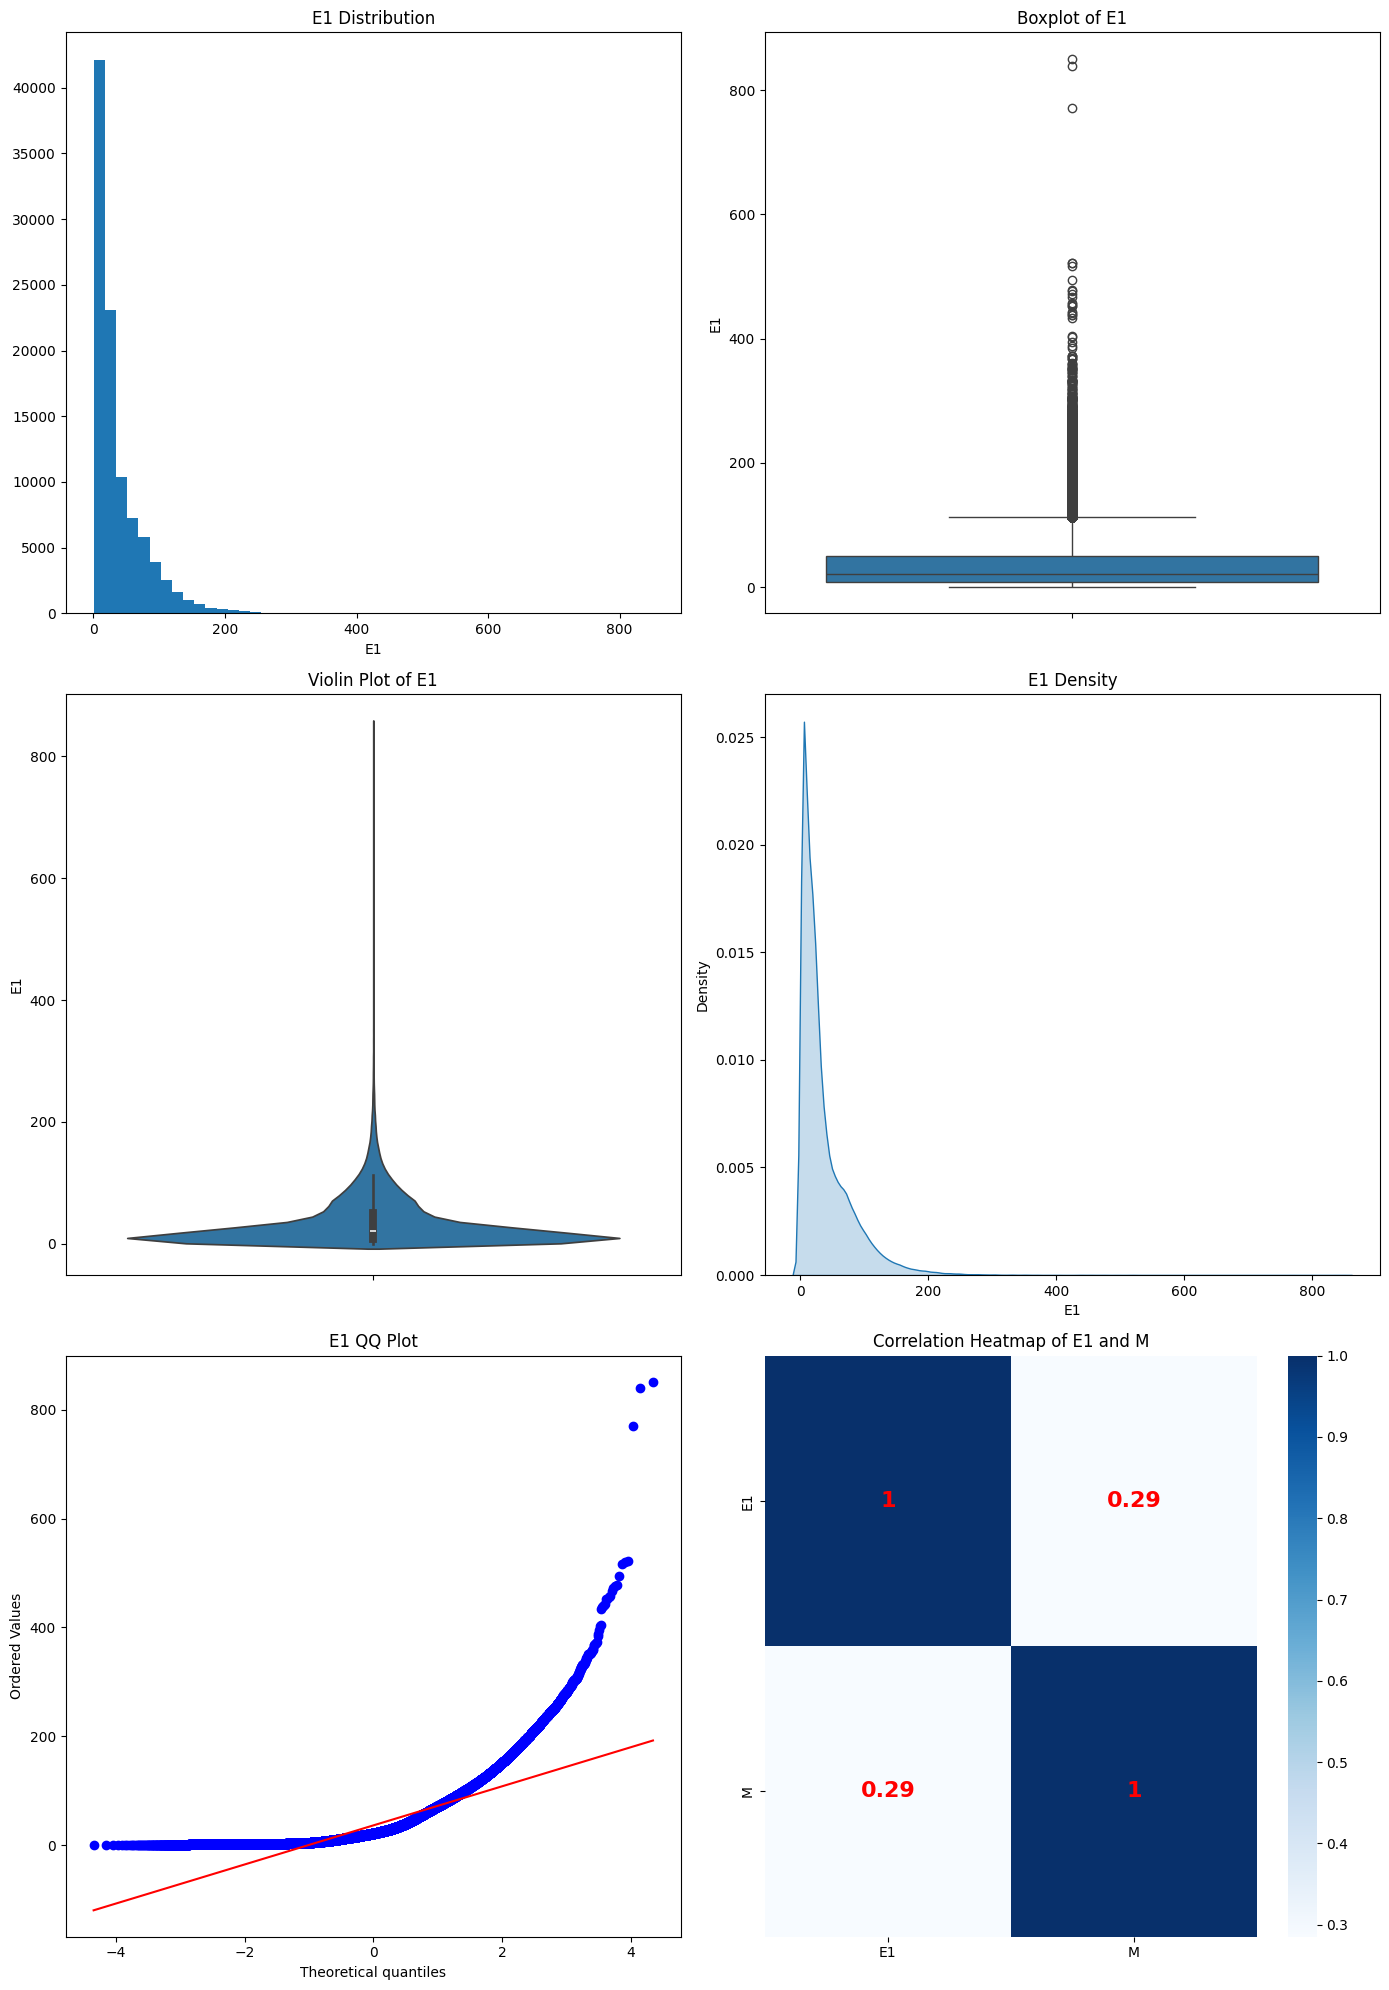

#####################################
count   99915.000
mean        0.136
std        13.409
min      -250.587
5%        -21.268
10%       -15.359
20%        -8.346
30%        -3.425
40%        -1.635
50%         0.142
60%         1.820
70%         3.708
80%         8.960
90%        15.631
95%        21.405
99%        37.917
max       134.539
Name: px1 , dtype: float64
Skewness: -0.12
Kurtosis: 5.34


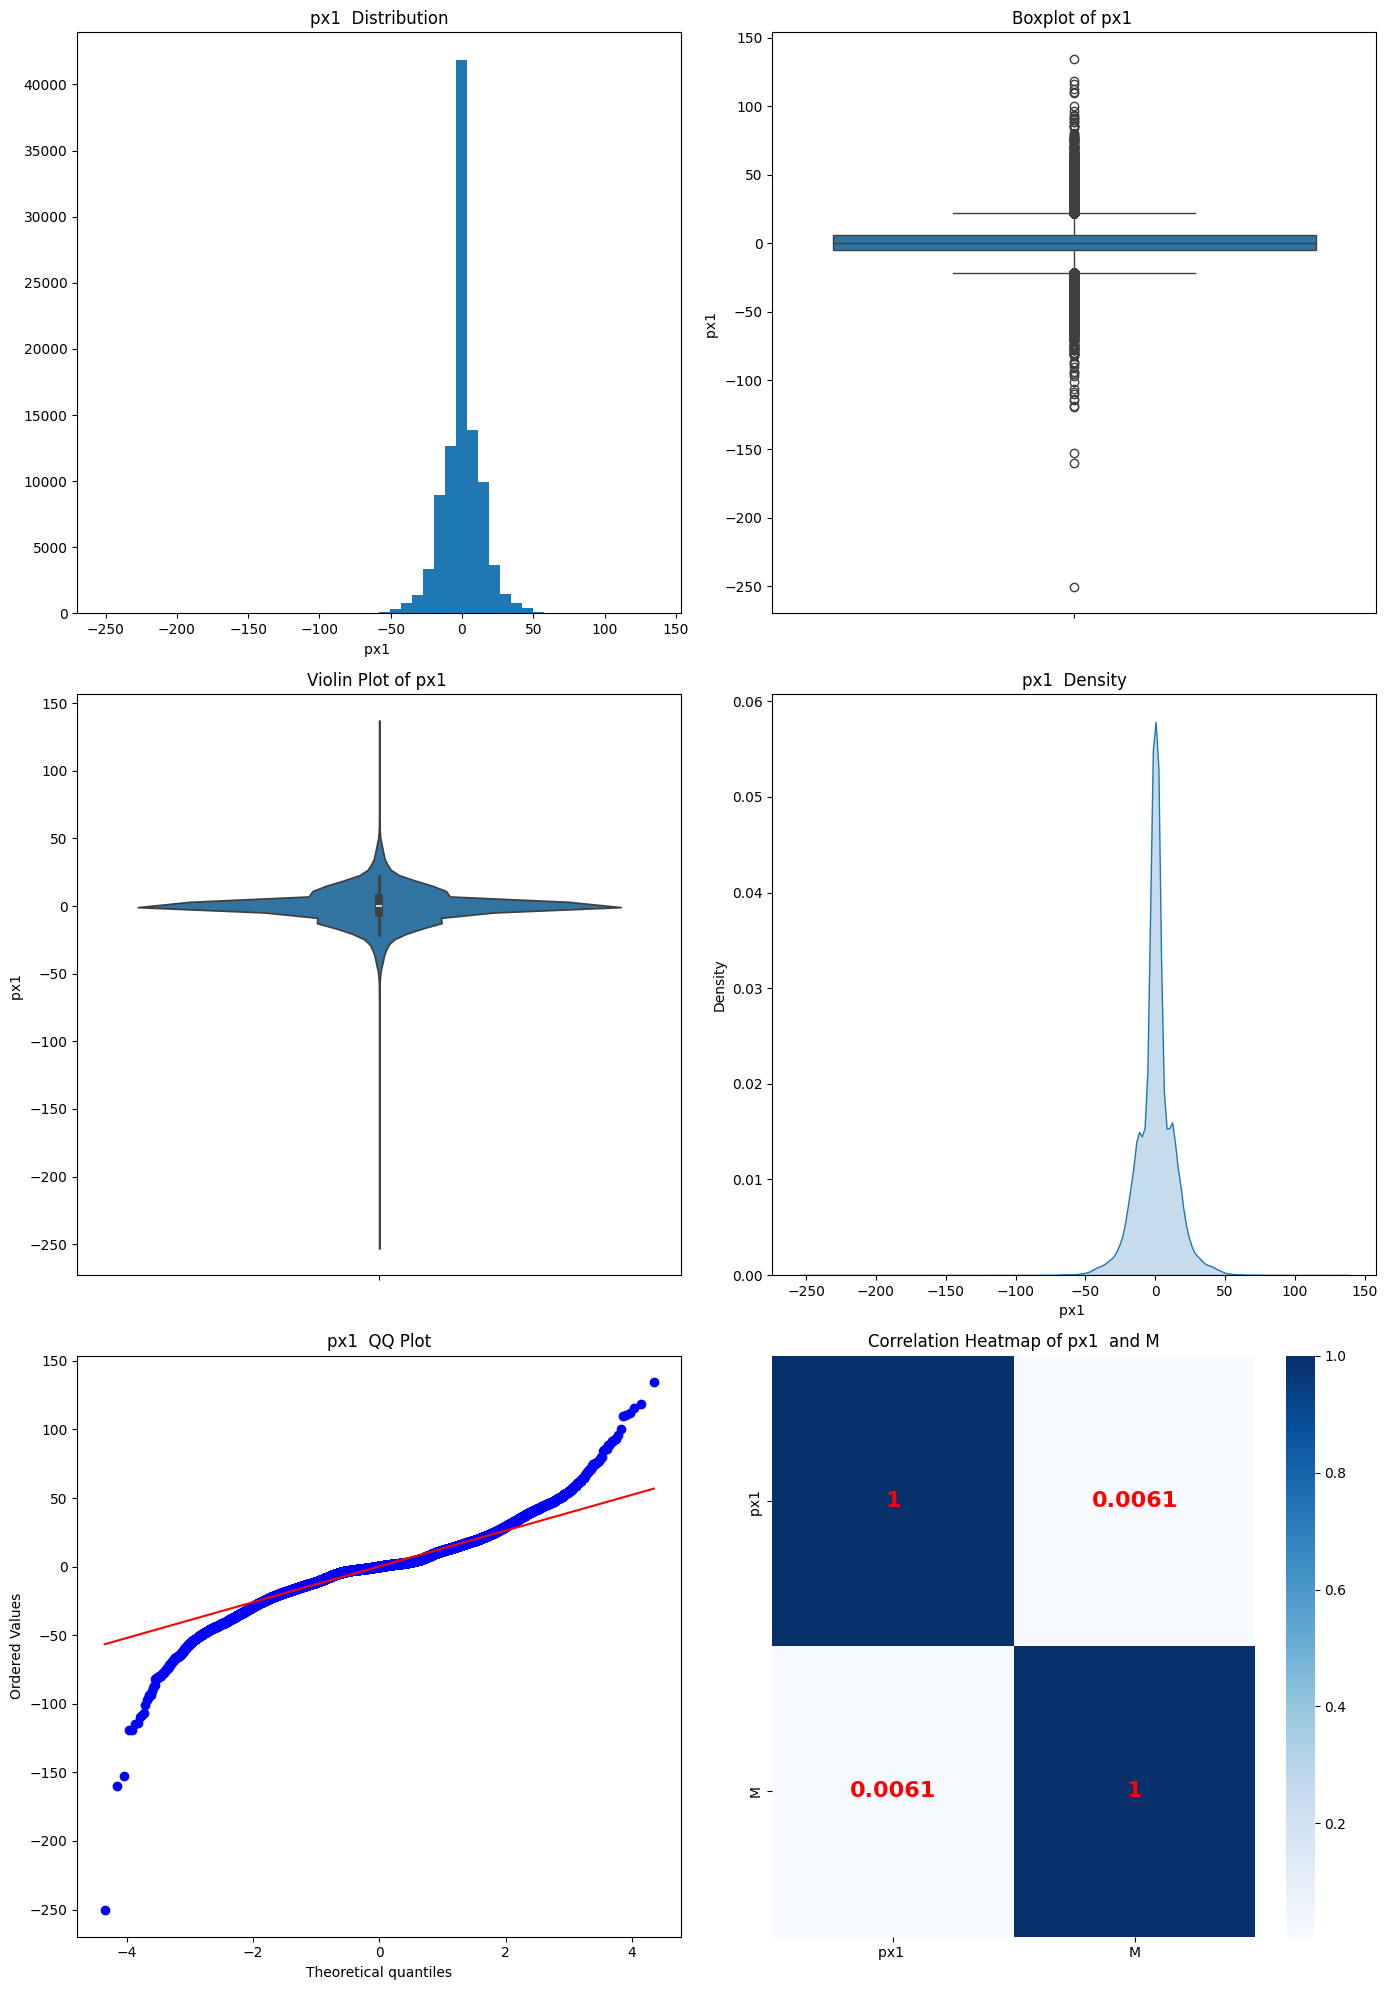

#####################################
count   99915.000
mean        0.183
std        13.475
min      -126.079
5%        -21.336
10%       -15.359
20%        -8.392
30%        -3.415
40%        -1.647
50%         0.101
60%         1.812
70%         3.677
80%         8.903
90%        15.872
95%        21.663
99%        38.092
max       147.467
Name: py1, dtype: float64
Skewness: 0.03
Kurtosis: 4.06


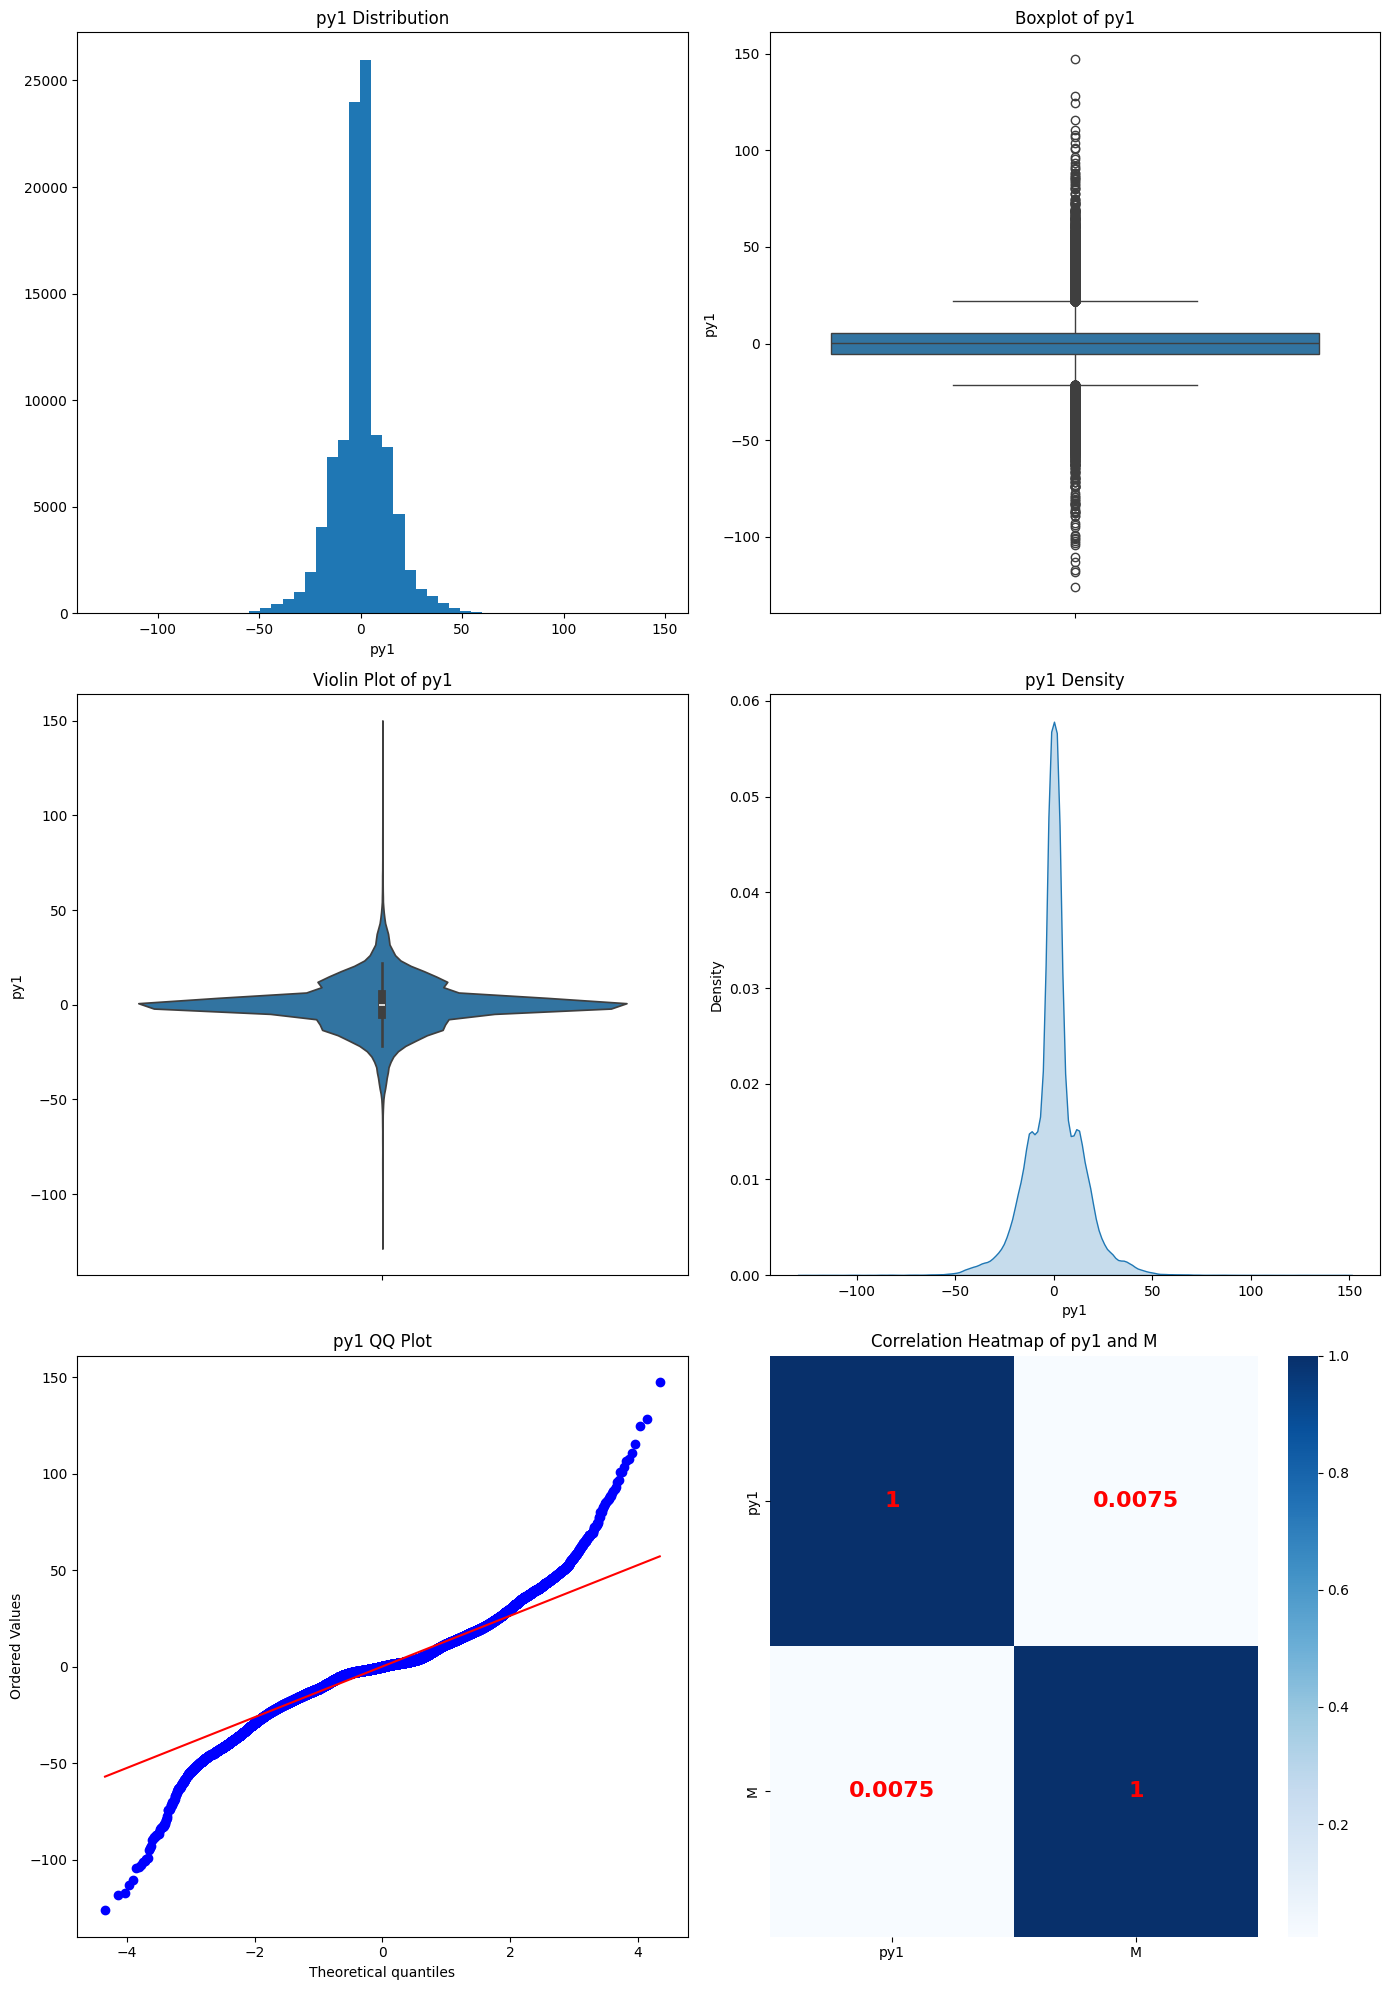

#####################################
count   99915.000
mean       -1.509
std        51.625
min      -840.987
5%        -89.365
10%       -58.845
20%       -22.874
30%       -10.838
40%        -3.760
50%        -0.313
60%         2.524
70%         8.768
80%        19.987
90%        52.784
95%        83.368
99%       150.156
max       760.096
Name: pz1, dtype: float64
Skewness: -0.05
Kurtosis: 7.73


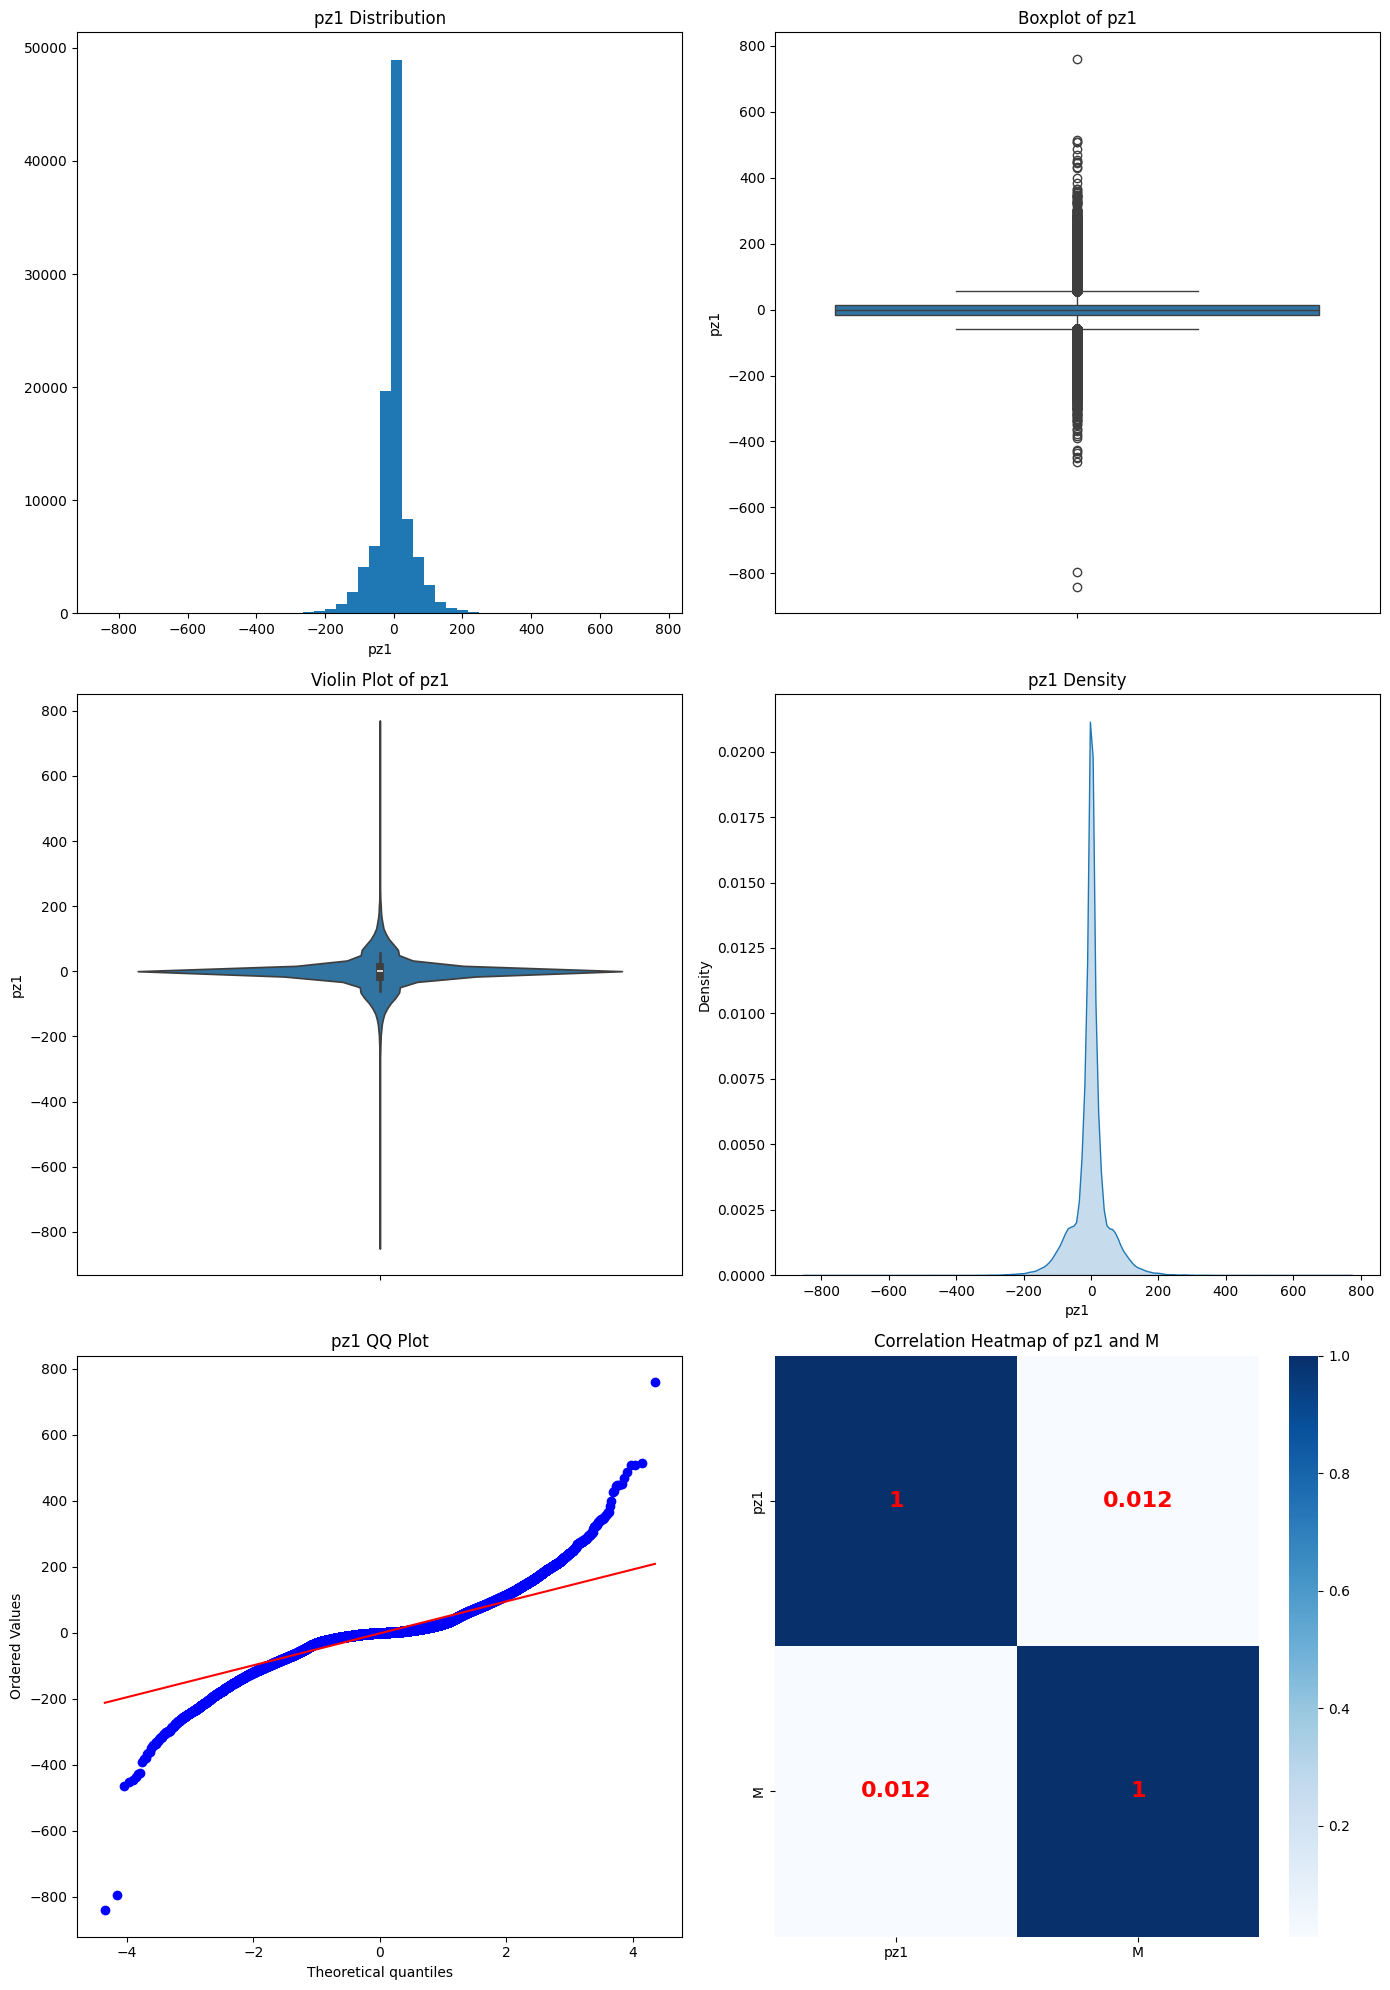

#####################################
count   99915.000
mean       14.418
std        12.391
min         0.220
5%          2.079
10%         2.410
20%         3.188
30%         4.554
40%         8.104
50%        12.973
60%        15.421
70%        18.503
80%        22.171
90%        30.337
95%        39.188
99%        52.553
max       265.578
Name: pt1, dtype: float64
Skewness: 1.74
Kurtosis: 7.29


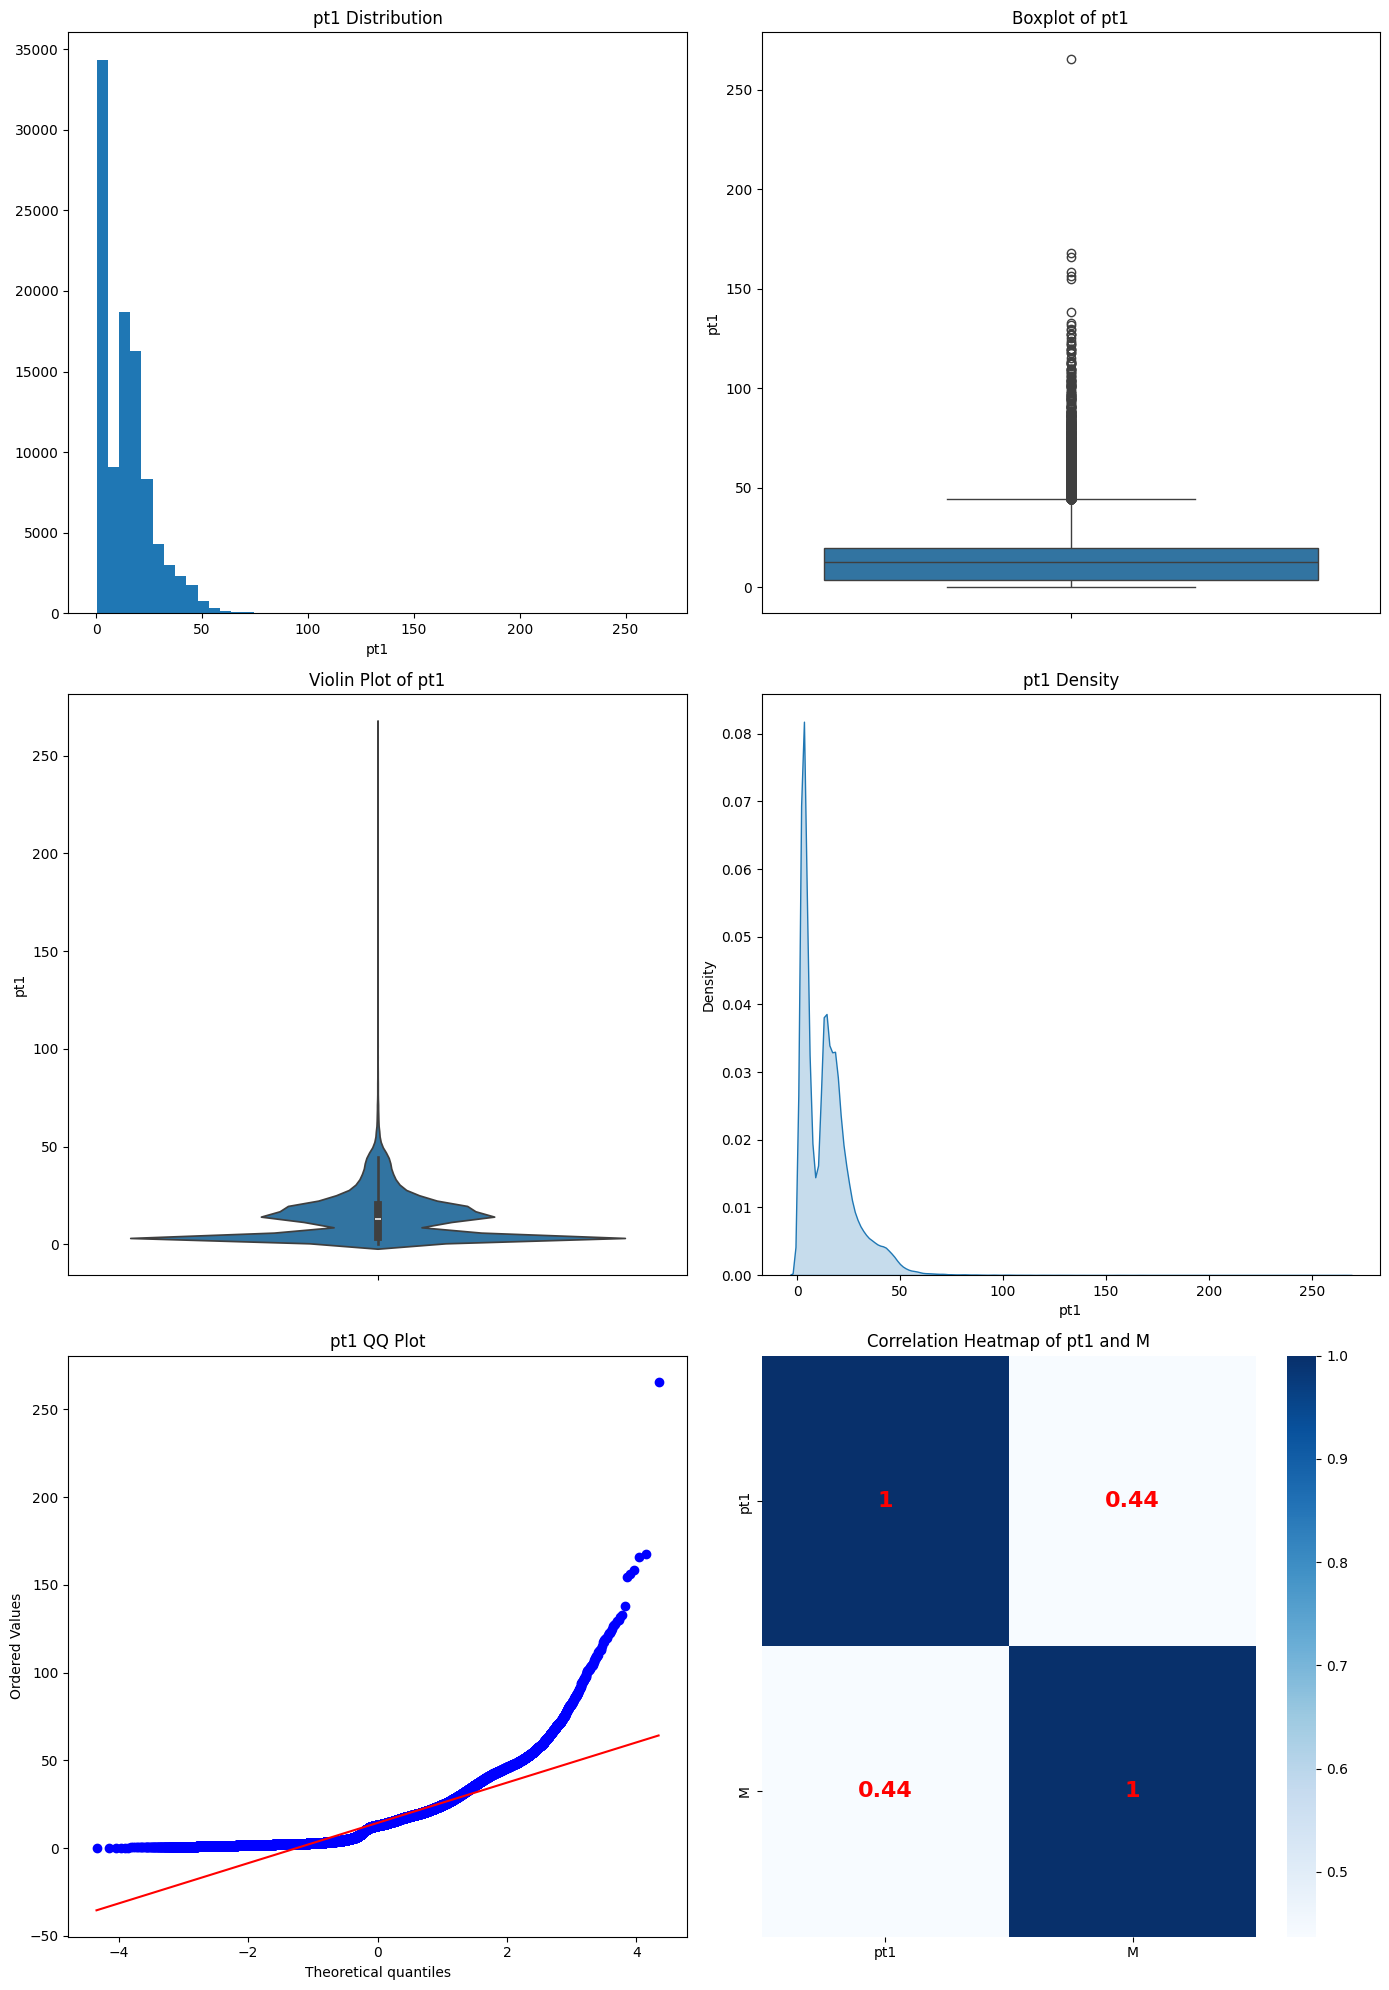

#####################################
count   99915.000
mean       -0.064
std         1.463
min        -4.165
5%         -2.312
10%        -2.108
20%        -1.601
30%        -1.059
40%        -0.565
50%        -0.061
60%         0.424
70%         0.915
80%         1.381
90%         2.016
95%         2.241
99%         2.460
max         2.623
Name: eta1, dtype: float64
Skewness: 0.02
Kurtosis: -1.17


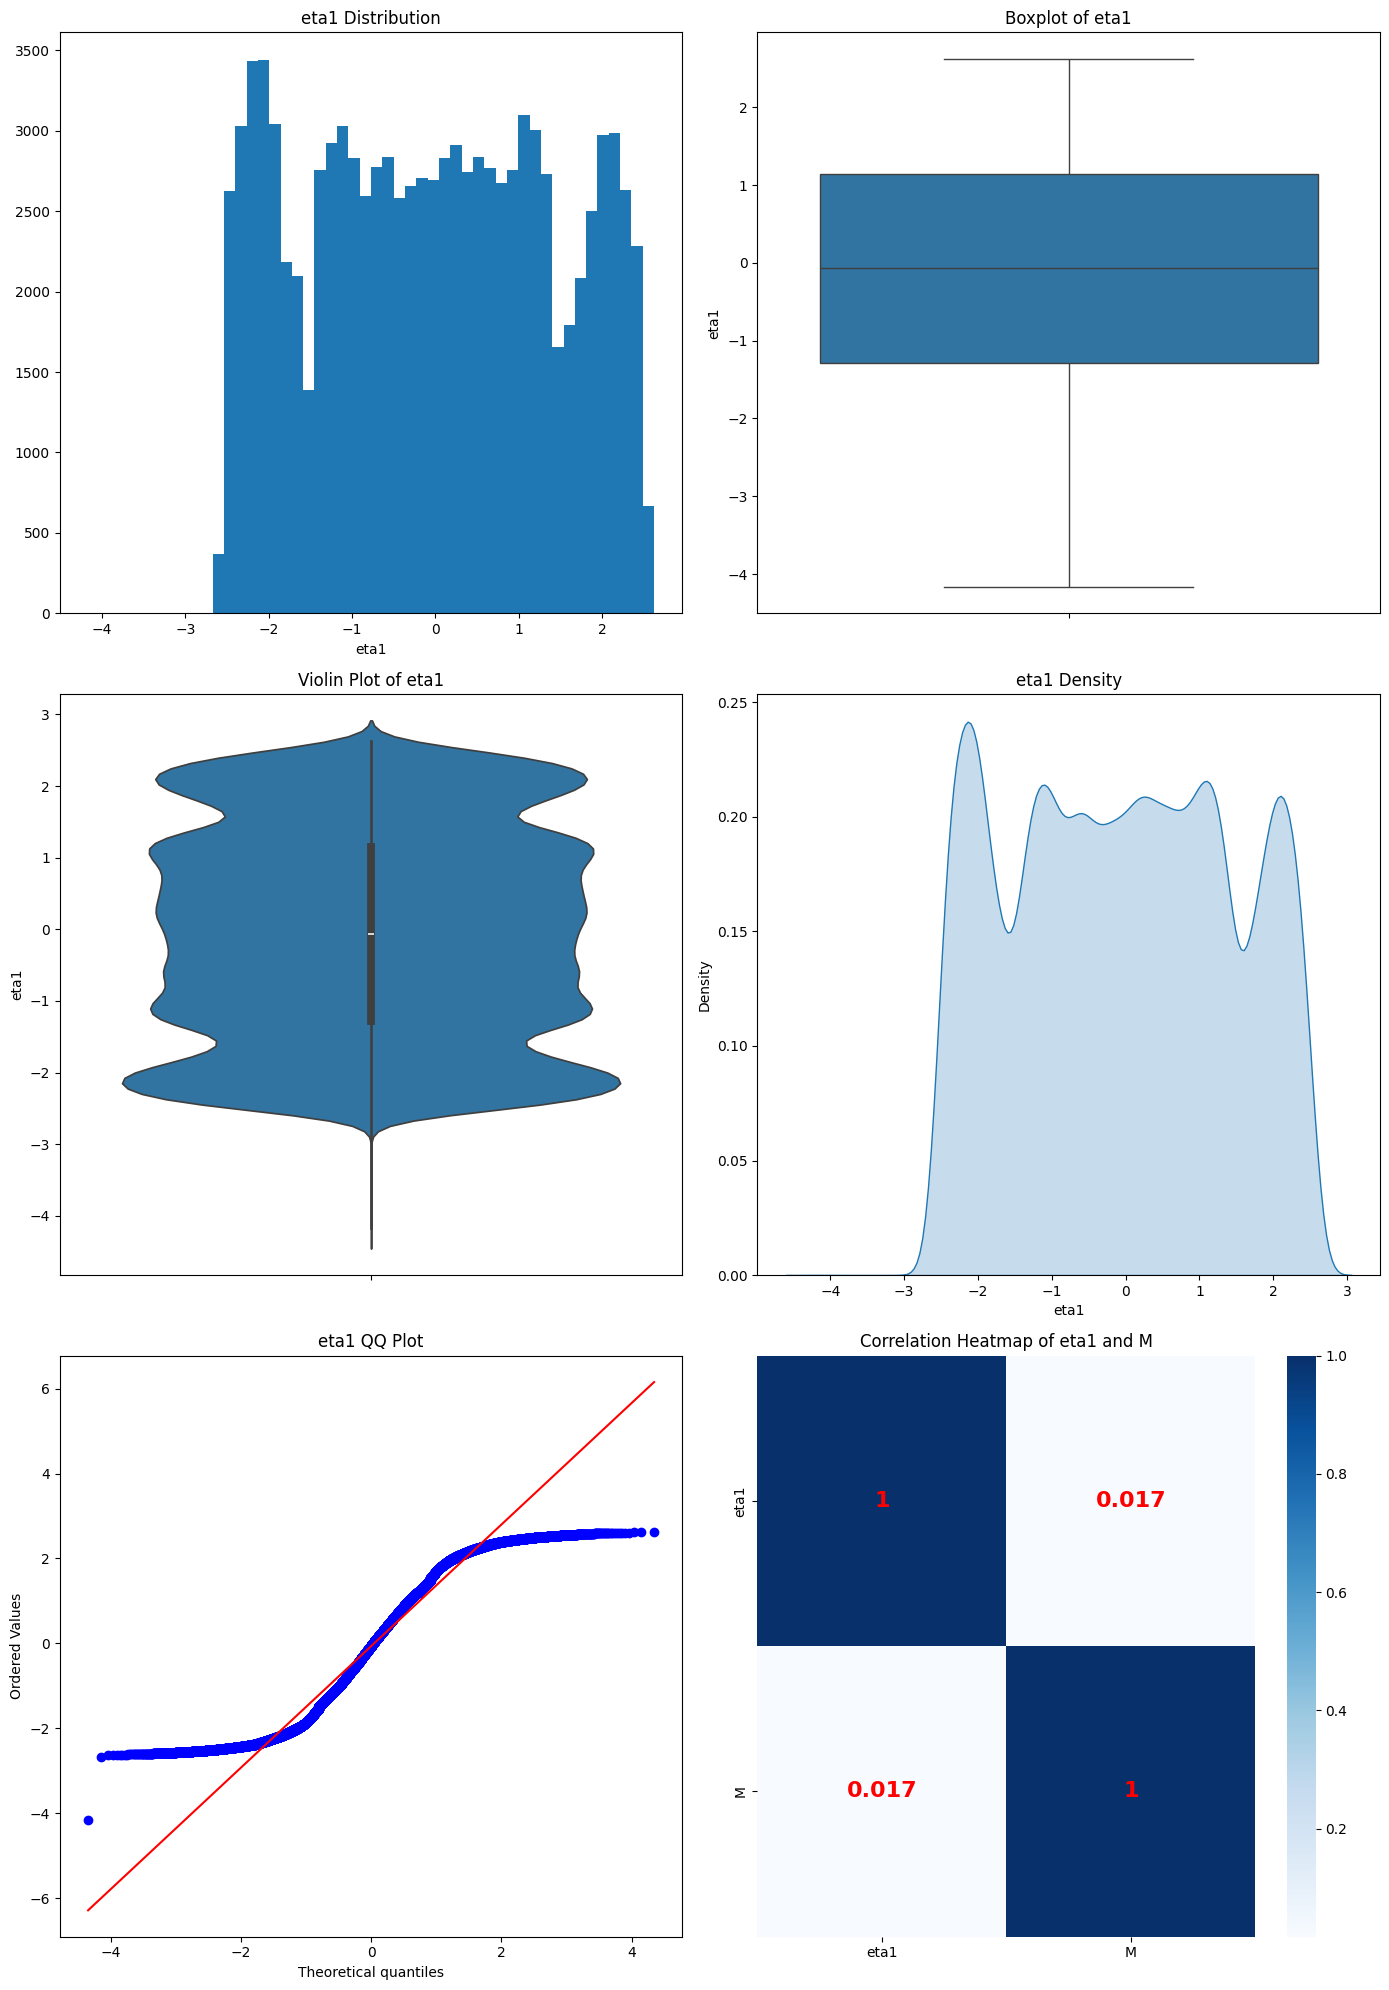

#####################################
count   99915.000
mean        0.022
std         1.800
min        -3.142
5%         -2.813
10%        -2.486
20%        -1.847
30%        -1.196
40%        -0.565
50%         0.035
60%         0.660
70%         1.271
80%         1.871
90%         2.498
95%         2.816
99%         3.076
max         3.141
Name: phi1, dtype: float64
Skewness: -0.02
Kurtosis: -1.18


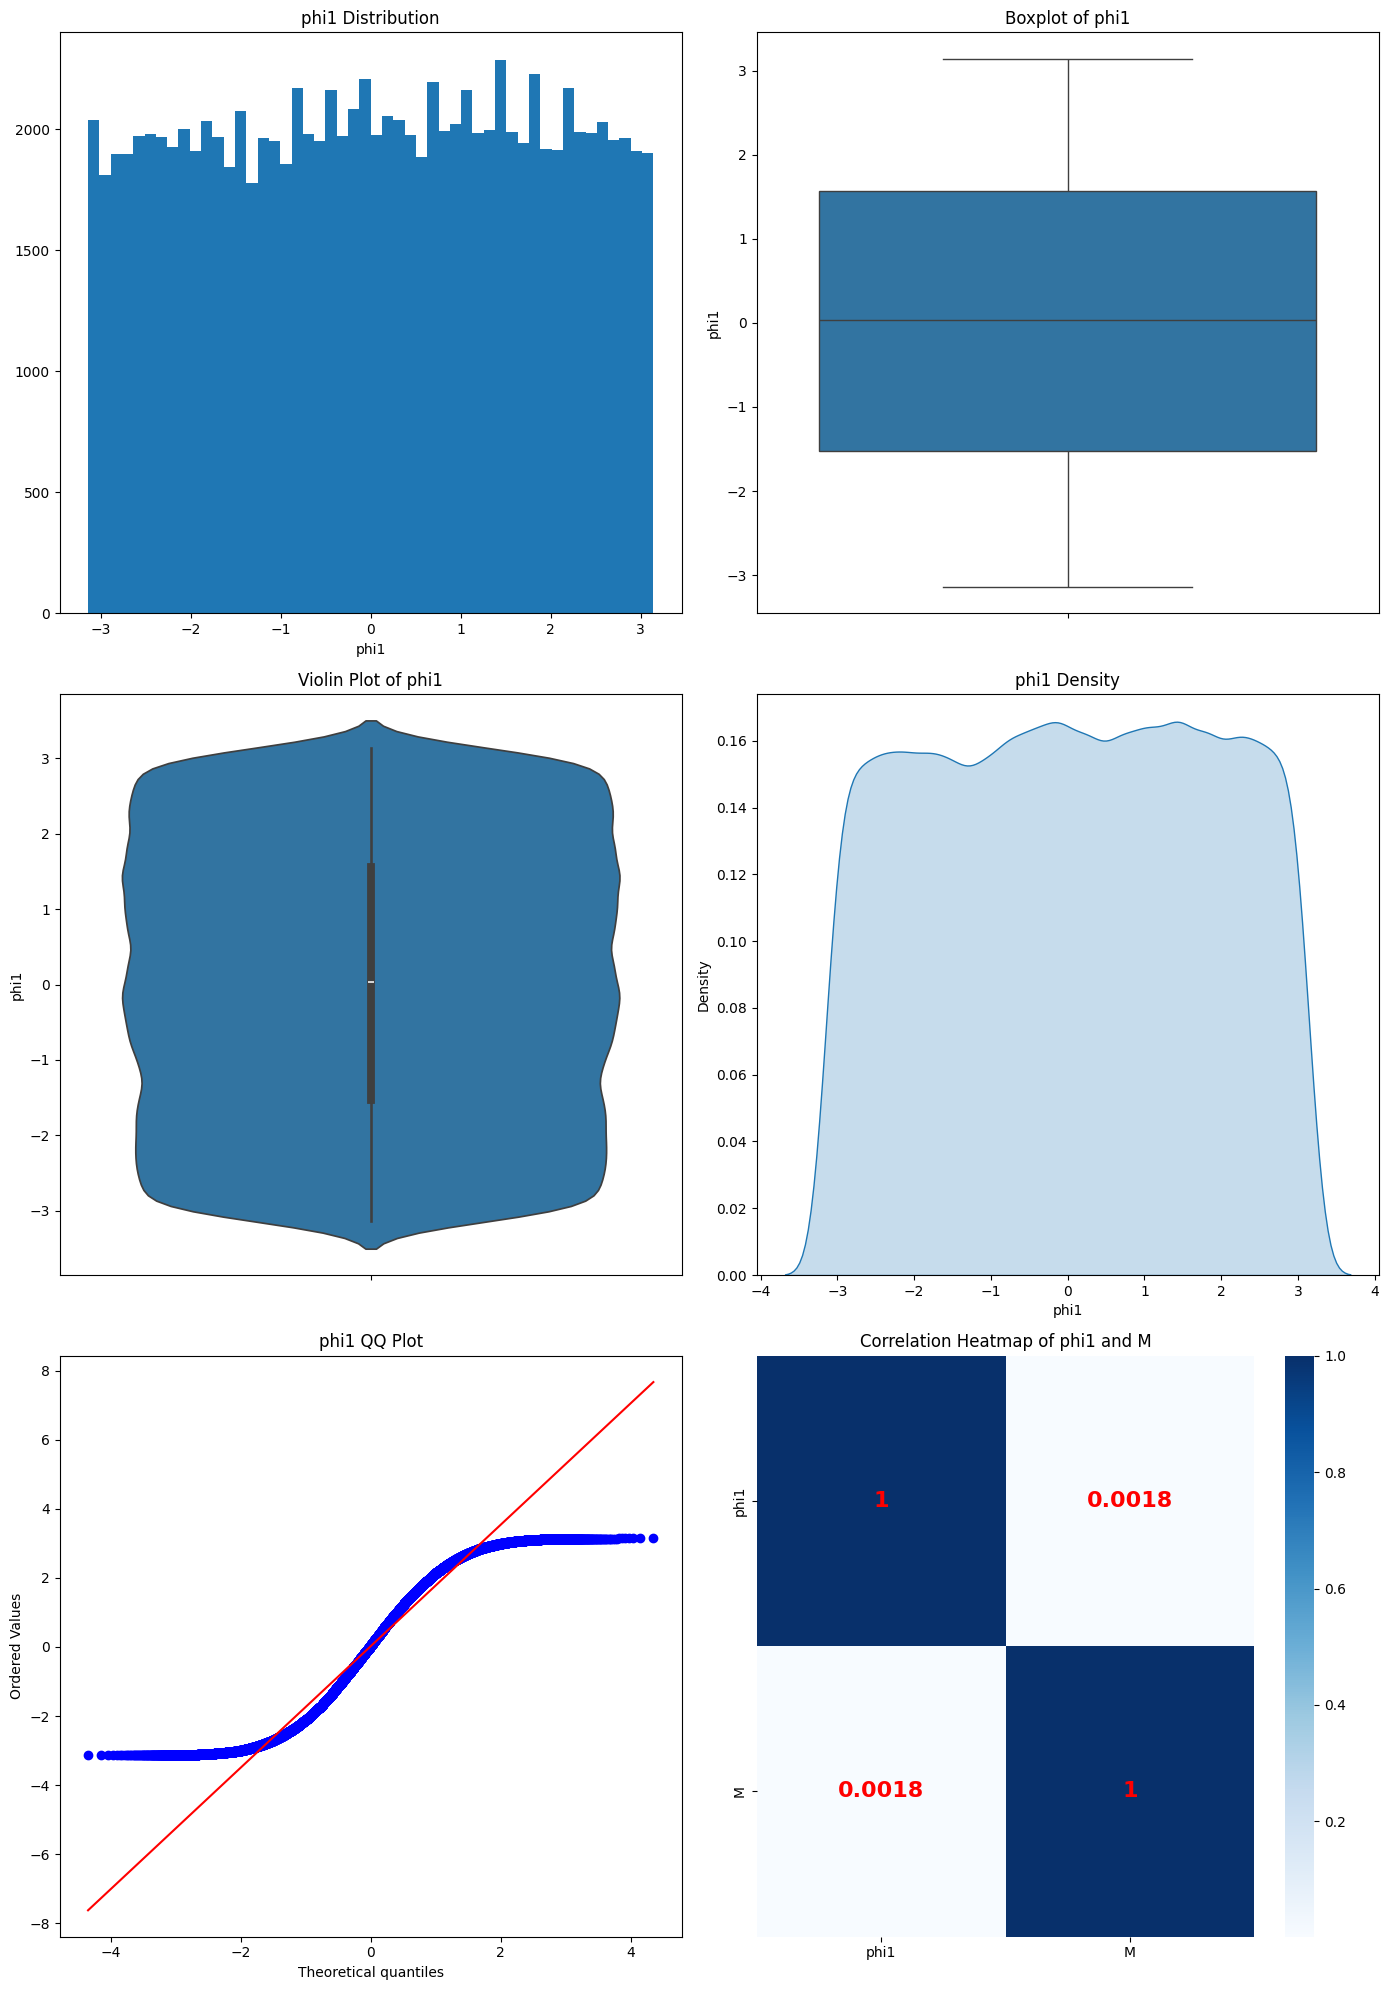

#####################################
count   99915.000
mean       44.029
std        46.762
min         0.472
5%          2.882
10%         4.348
20%         9.044
30%        13.220
40%        18.433
50%        25.291
60%        37.058
70%        56.871
80%        76.870
90%       104.974
95%       133.202
99%       207.315
max       948.375
Name: E2, dtype: float64
Skewness: 2.21
Kurtosis: 9.92


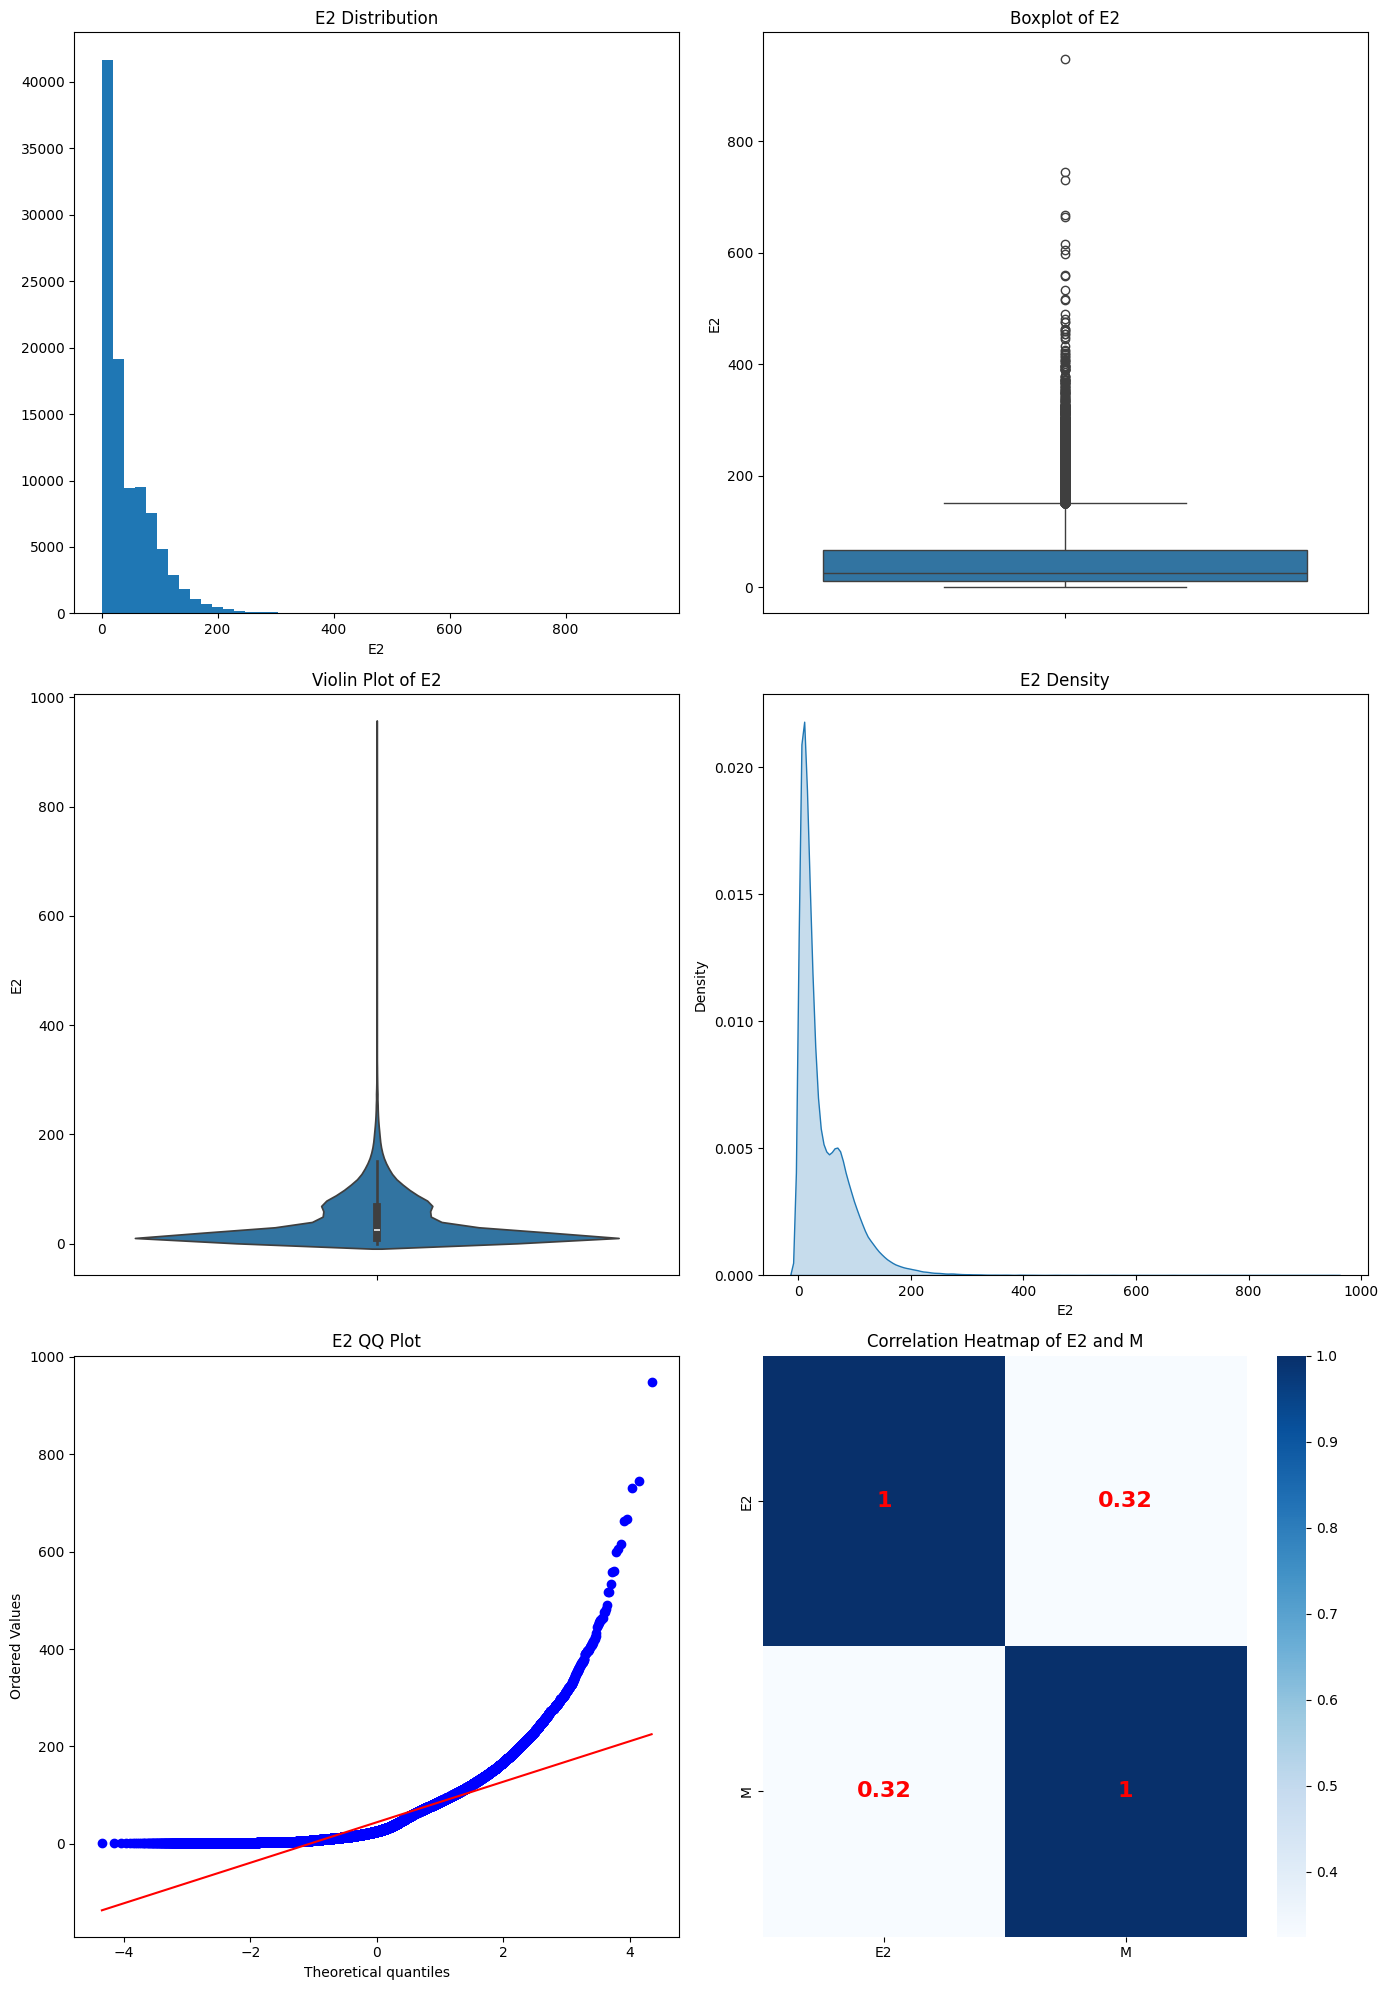

#####################################
count   99915.000
mean       -0.003
std        13.130
min      -233.730
5%        -20.861
10%       -14.994
20%        -7.422
30%        -3.317
40%        -1.735
50%        -0.036
60%         1.649
70%         3.334
80%         7.592
90%        14.964
95%        20.835
99%        37.521
max       227.330
Name: px2, dtype: float64
Skewness: -0.06
Kurtosis: 7.26


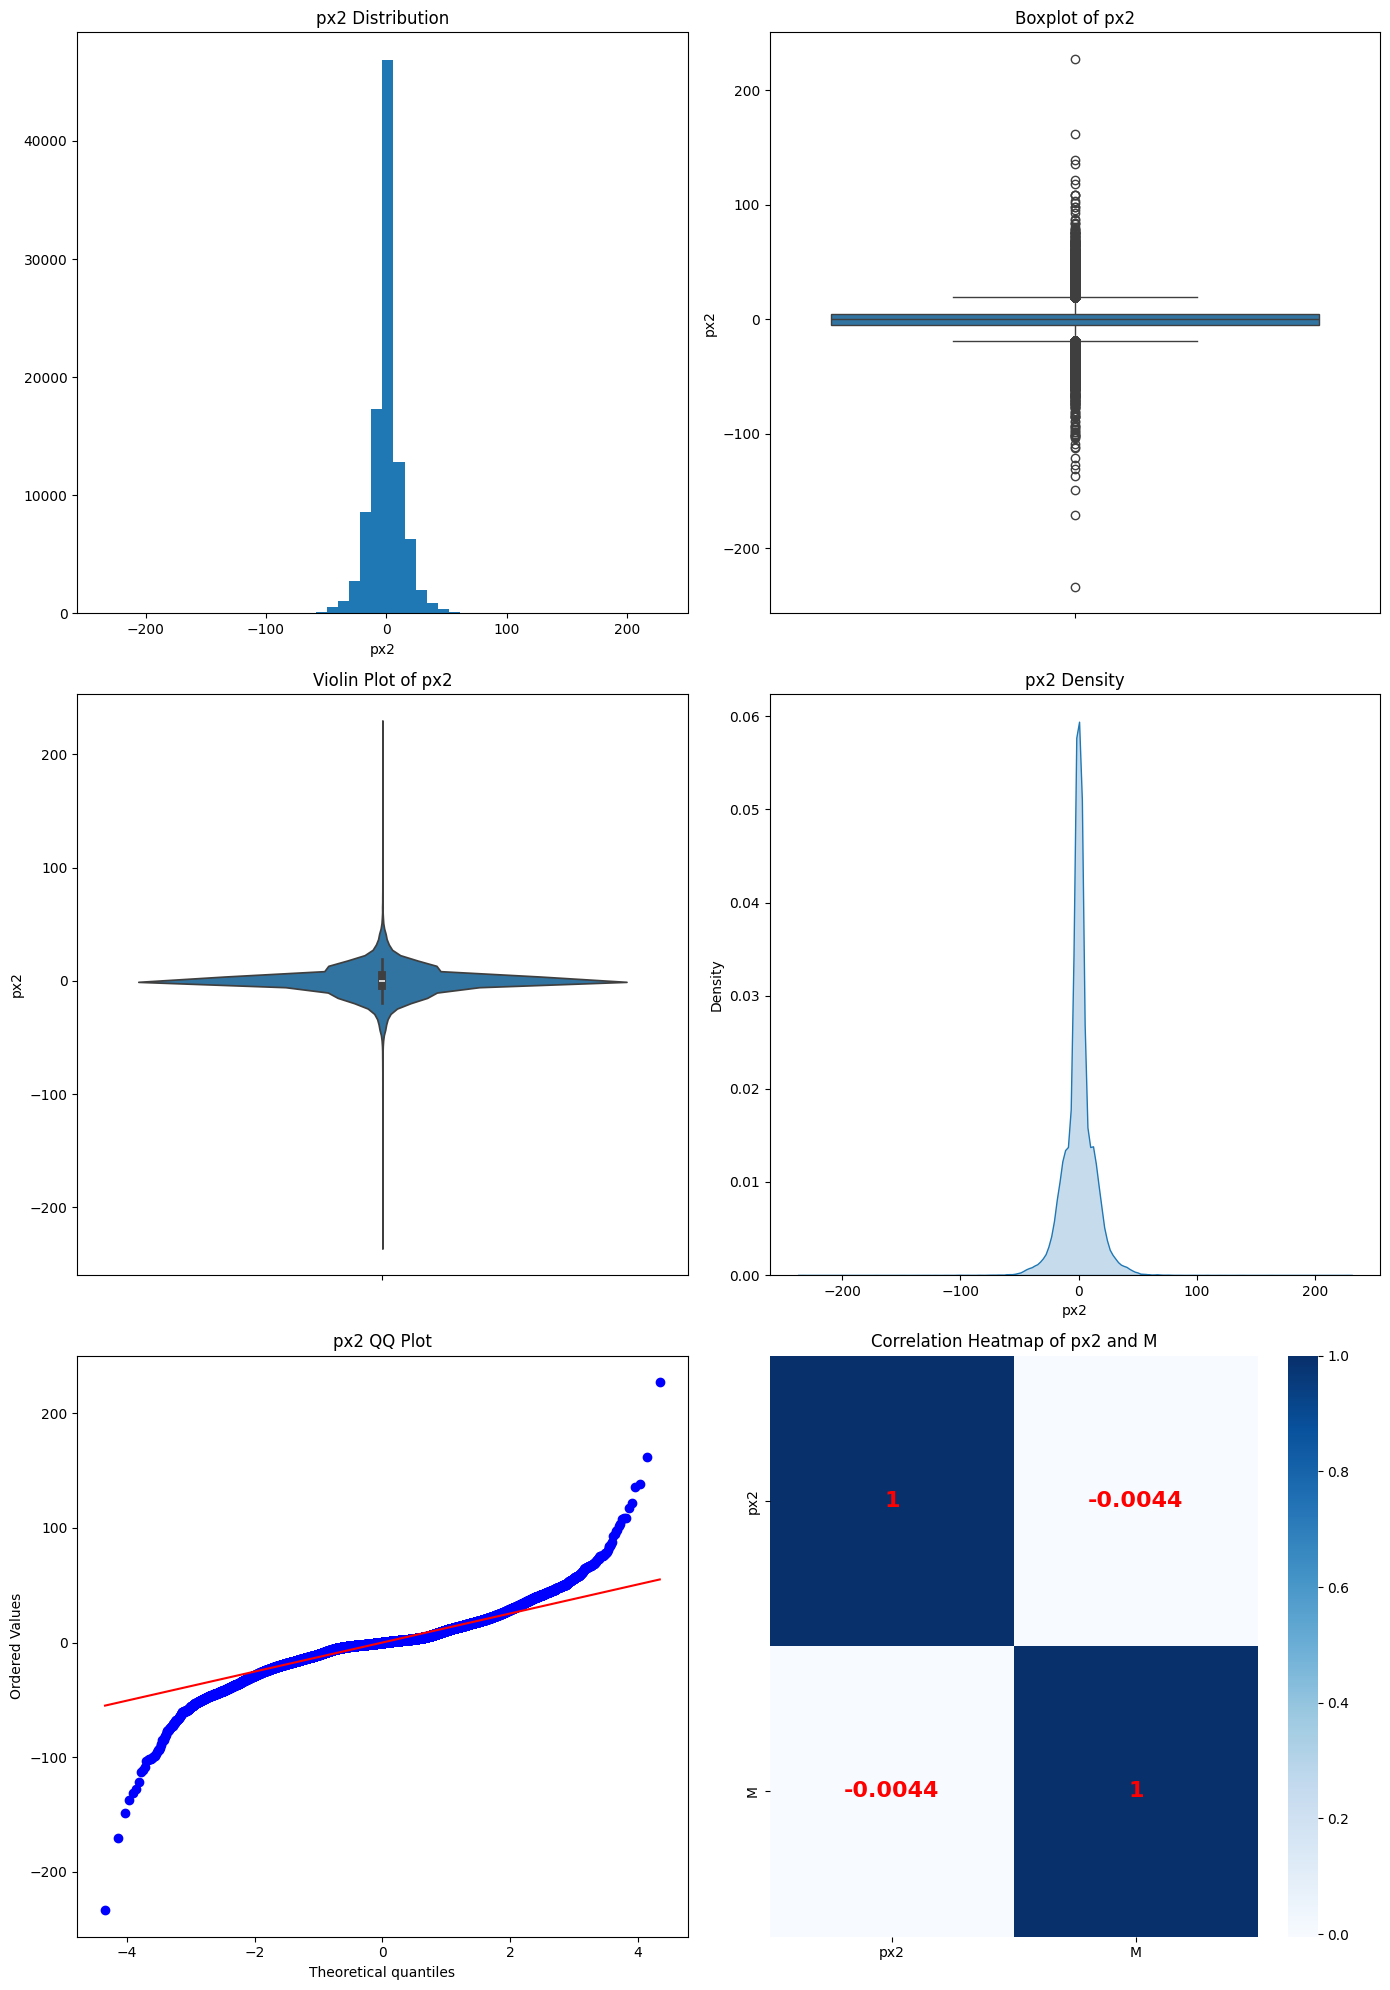

#####################################
count   99915.000
mean        0.126
std        13.172
min      -145.651
5%        -20.994
10%       -14.922
20%        -7.266
30%        -3.185
40%        -1.623
50%         0.085
60%         1.817
70%         3.526
80%         7.797
90%        15.301
95%        21.107
99%        37.271
max       166.283
Name: py2, dtype: float64
Skewness: -0.04
Kurtosis: 5.24


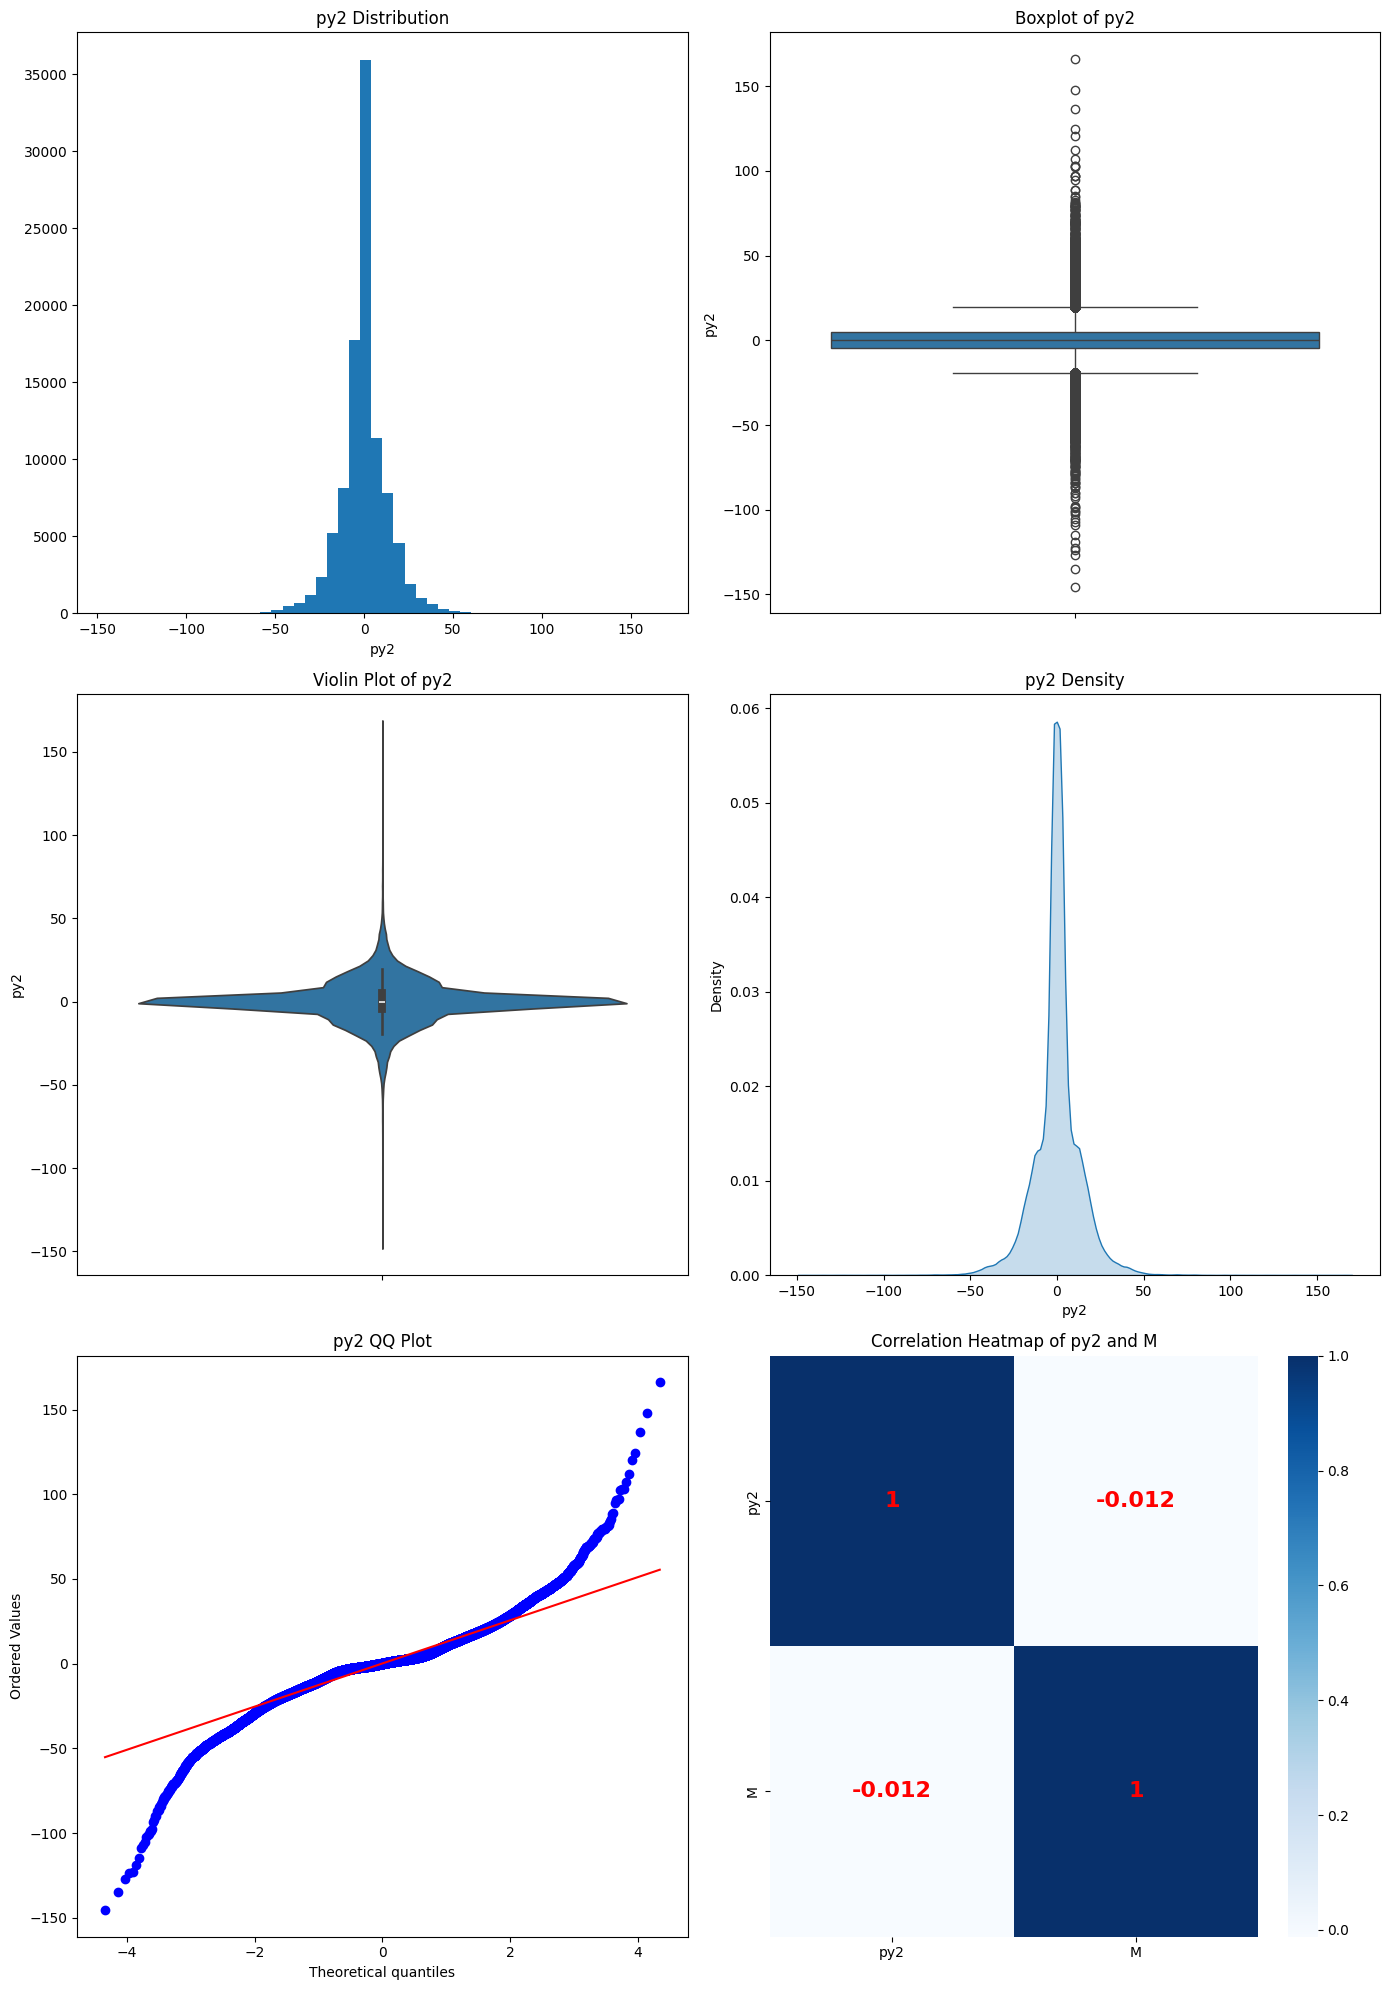

#####################################
count   99915.000
mean       -1.592
std        61.455
min      -655.396
5%       -103.717
10%       -75.604
20%       -33.219
30%       -15.482
40%        -7.490
50%        -0.692
60%         4.511
70%        13.029
80%        28.450
90%        71.937
95%        99.827
99%       167.939
max       935.558
Name: pz2, dtype: float64
Skewness: 0.07
Kurtosis: 5.29


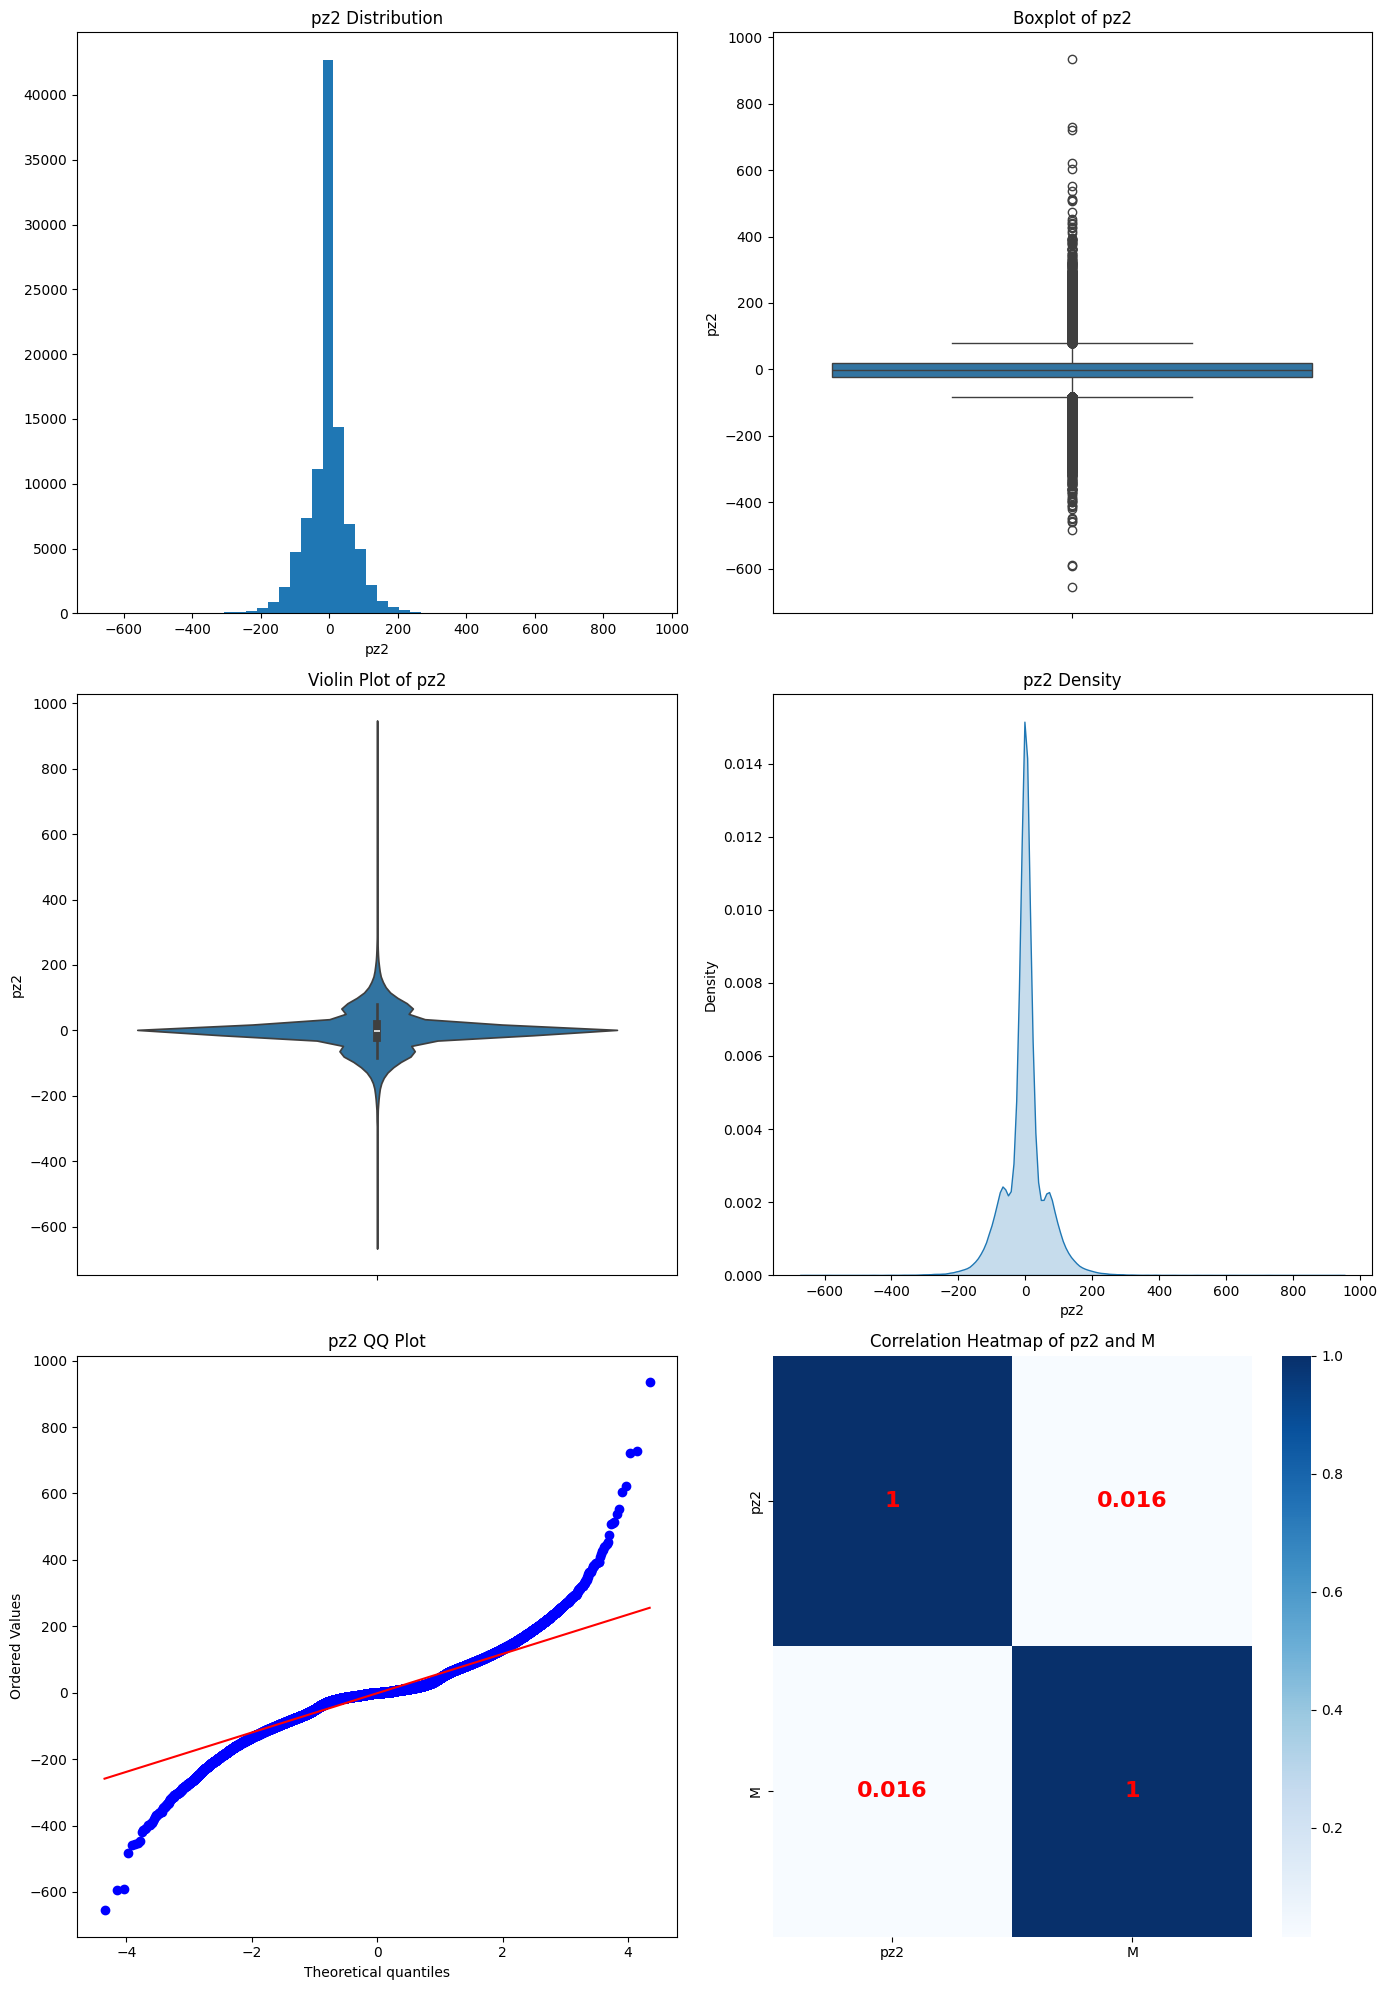

#####################################
count   99915.000
mean       13.805
std        12.464
min         0.027
5%          2.126
10%         2.489
20%         3.233
30%         4.345
40%         6.286
50%        11.691
60%        14.611
70%        18.009
80%        21.689
90%        29.362
95%        38.806
99%        53.015
max       281.654
Name: pt2, dtype: float64
Skewness: 1.99
Kurtosis: 9.96


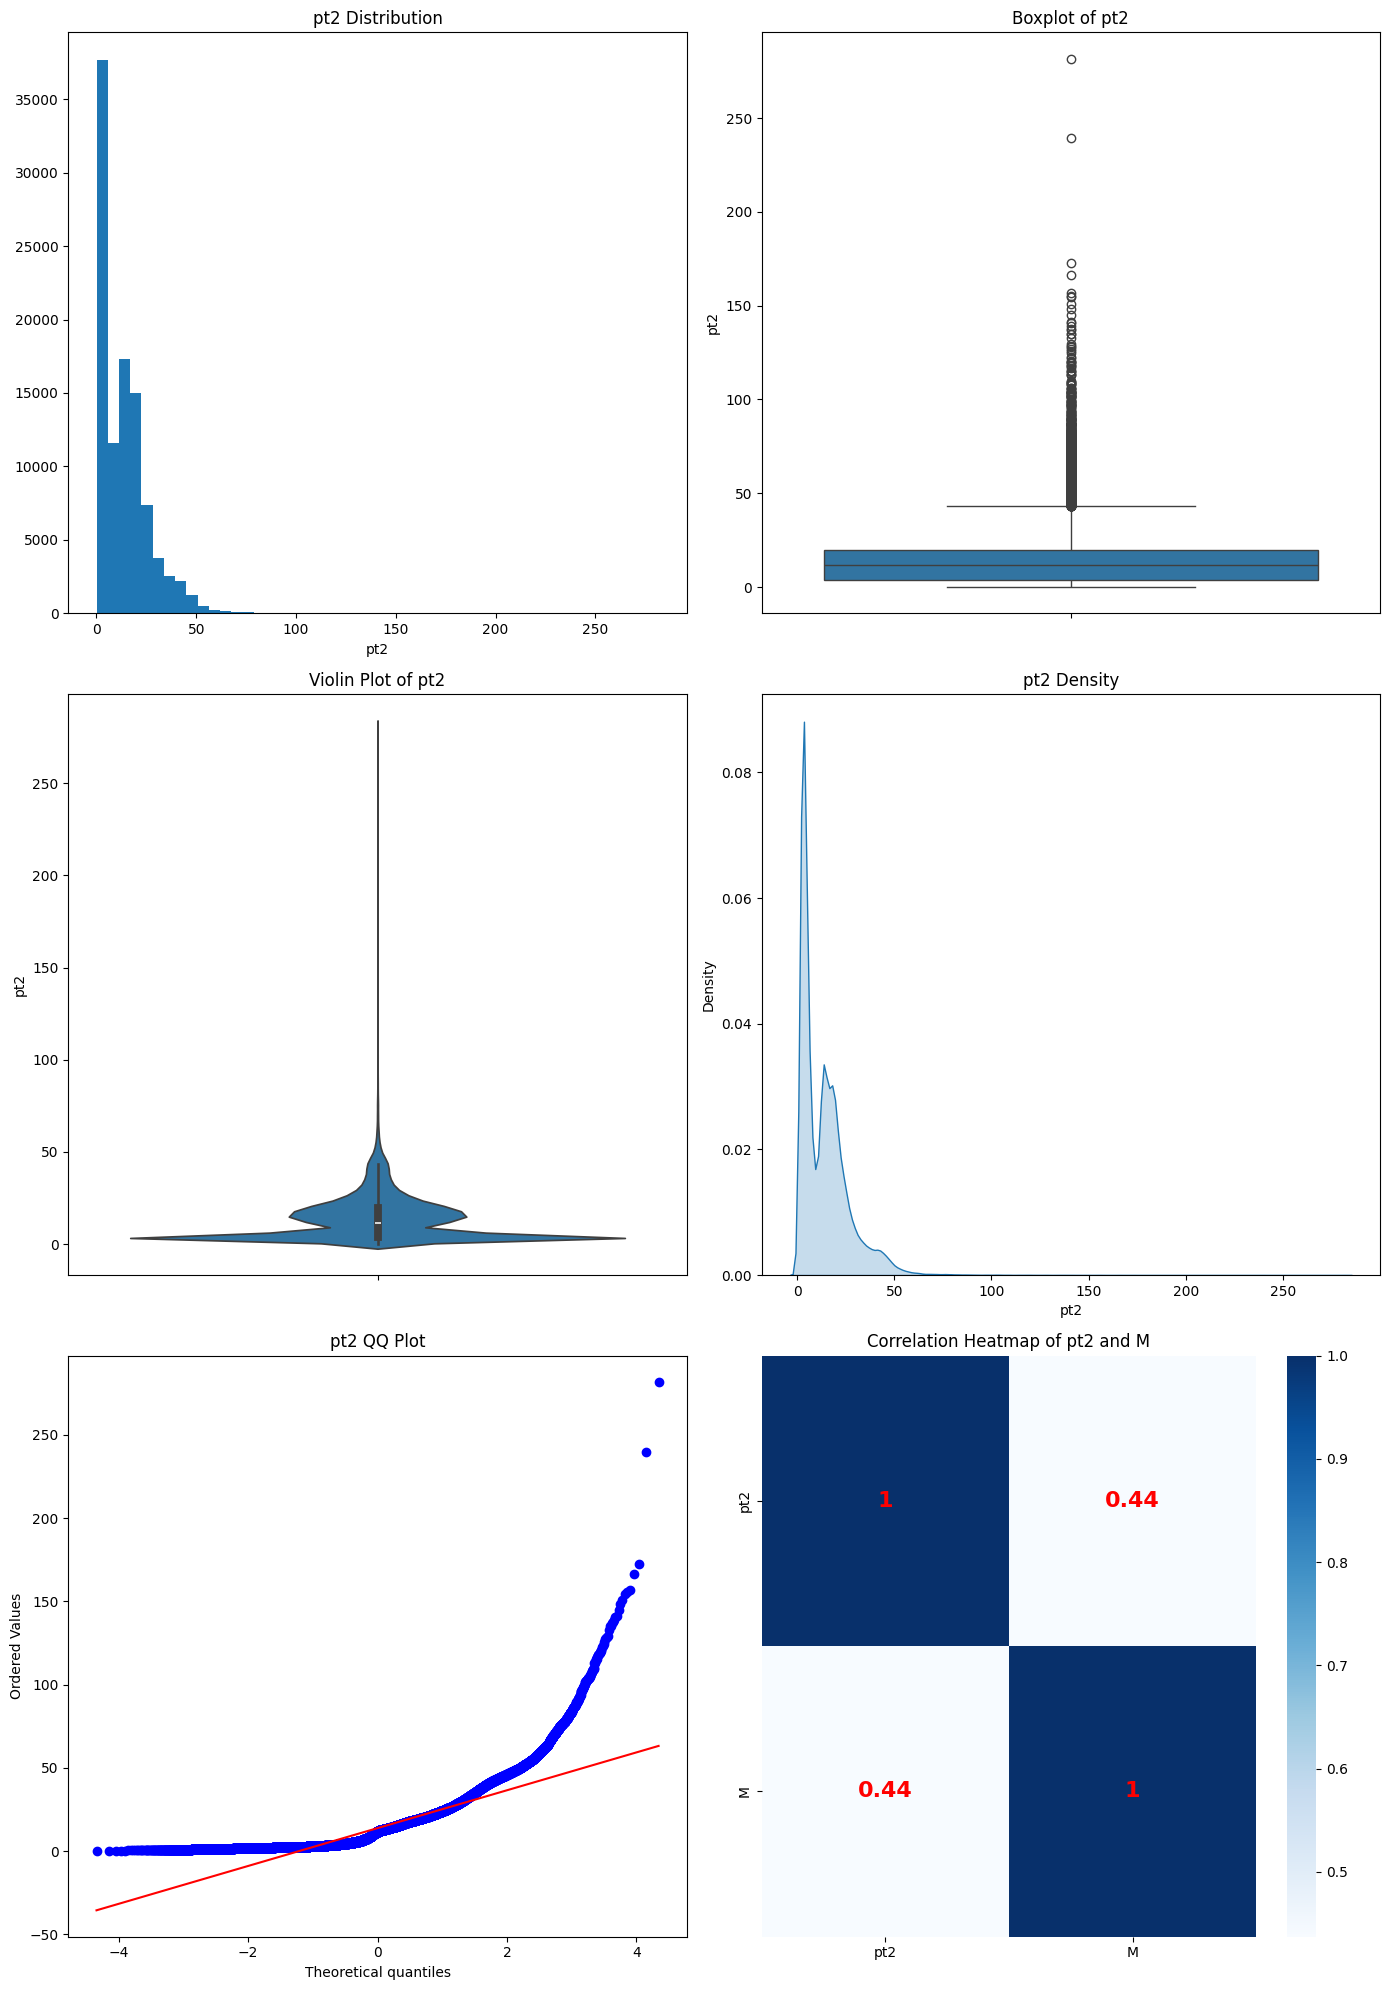

#####################################
count   99915.000
mean       -0.073
std         1.739
min        -7.065
5%         -2.379
10%        -2.264
20%        -2.038
30%        -1.679
40%        -0.928
50%        -0.137
60%         0.681
70%         1.414
80%         1.964
90%         2.224
95%         2.352
99%         2.468
max         3.061
Name: eta2, dtype: float64
Skewness: 0.05
Kurtosis: -1.55


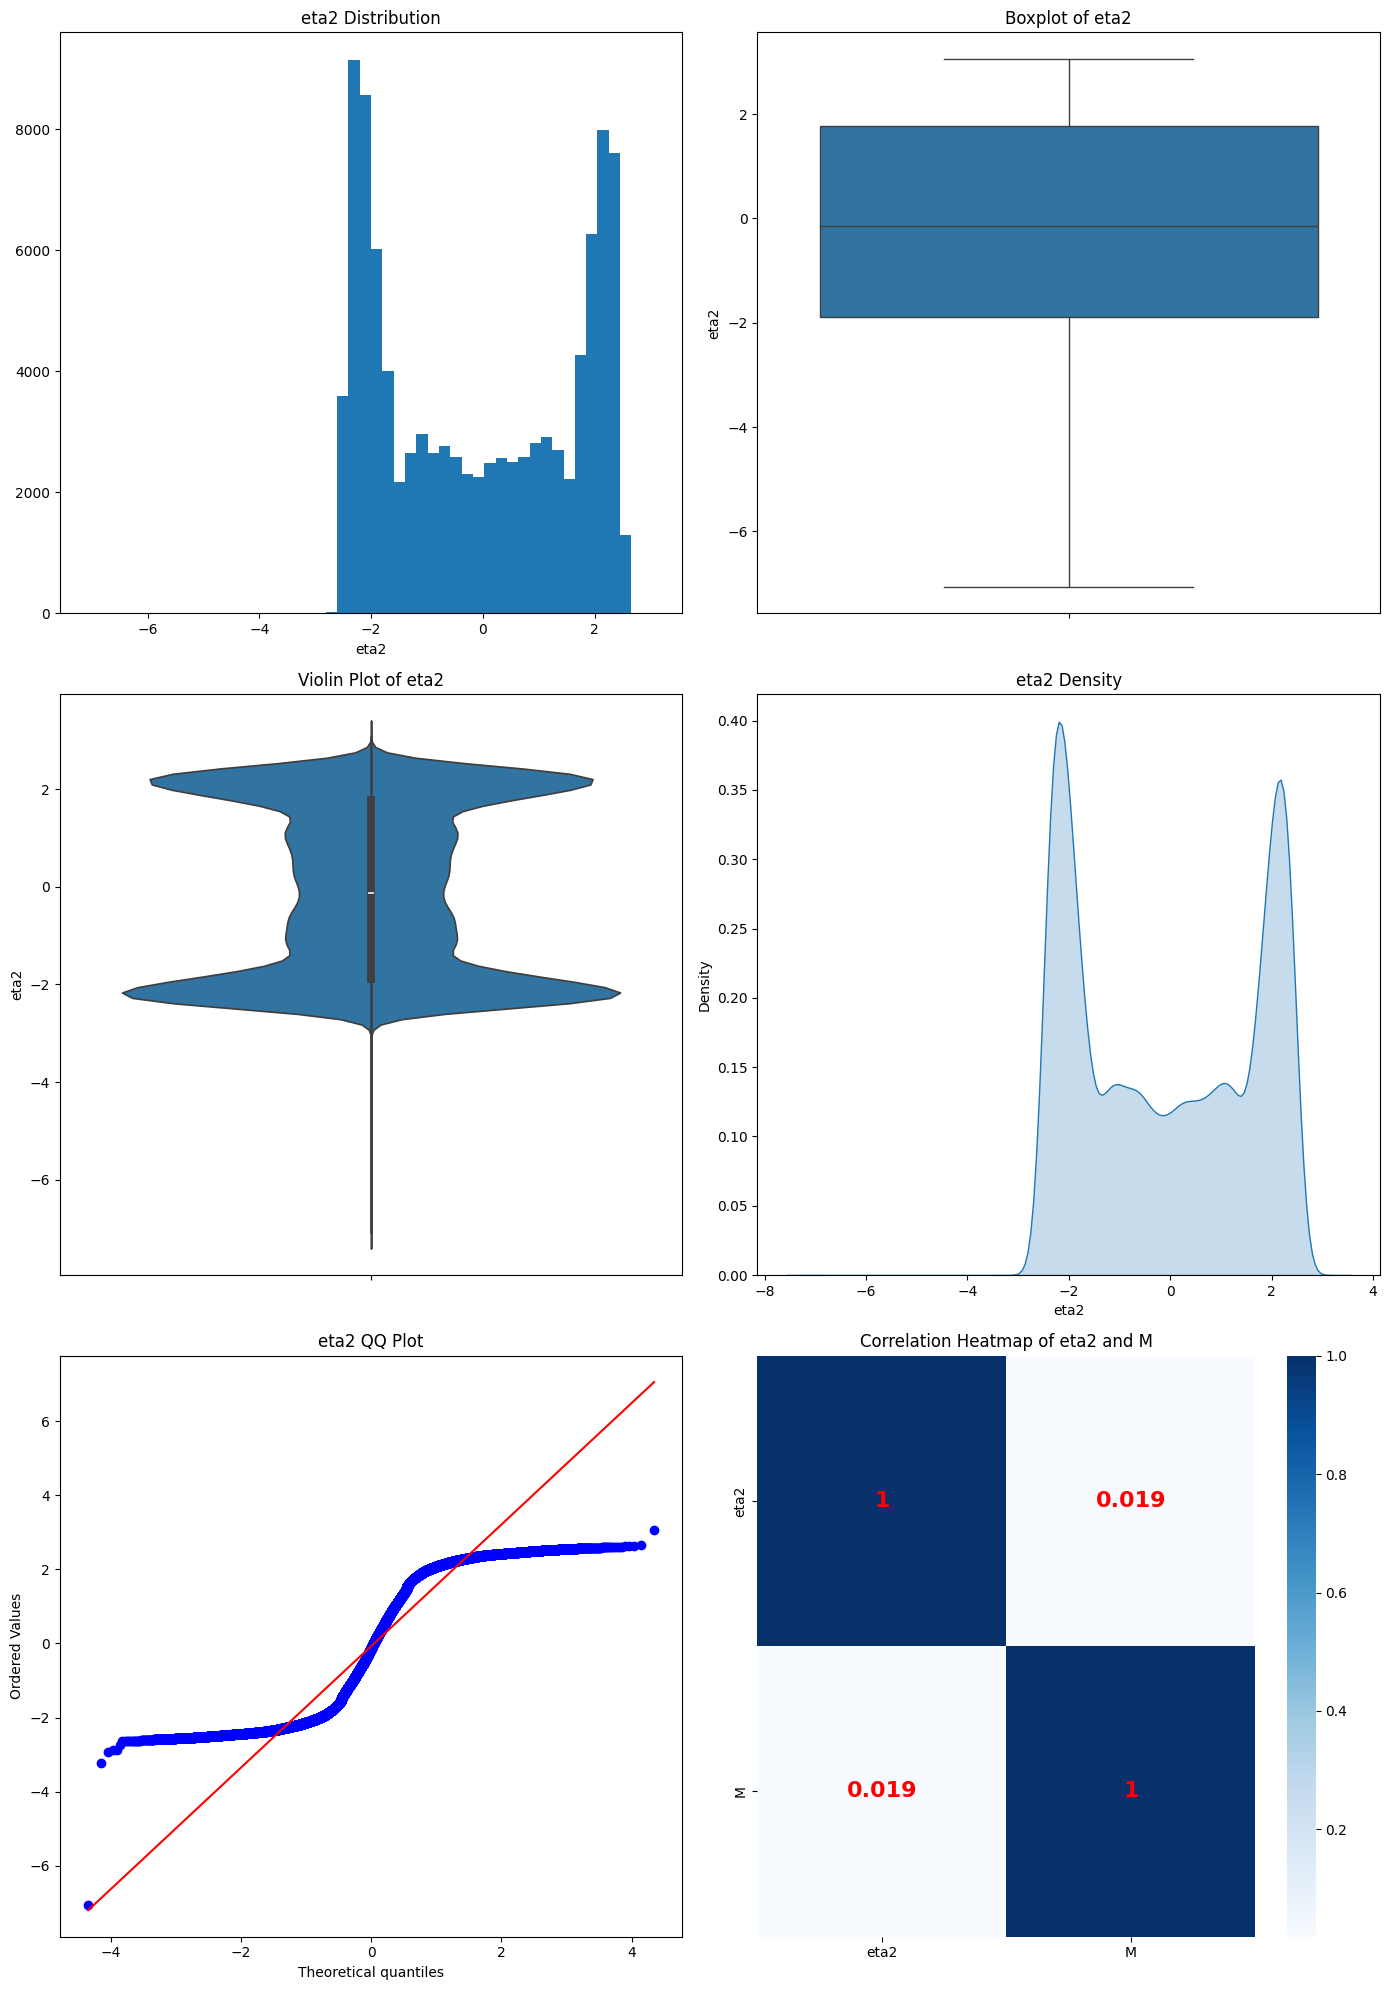

#####################################
count   99915.000
mean        0.022
std         1.817
min        -3.142
5%         -2.819
10%        -2.499
20%        -1.875
30%        -1.240
40%        -0.597
50%         0.027
60%         0.680
70%         1.307
80%         1.902
90%         2.521
95%         2.827
99%         3.076
max         3.141
Name: phi2, dtype: float64
Skewness: -0.02
Kurtosis: -1.21


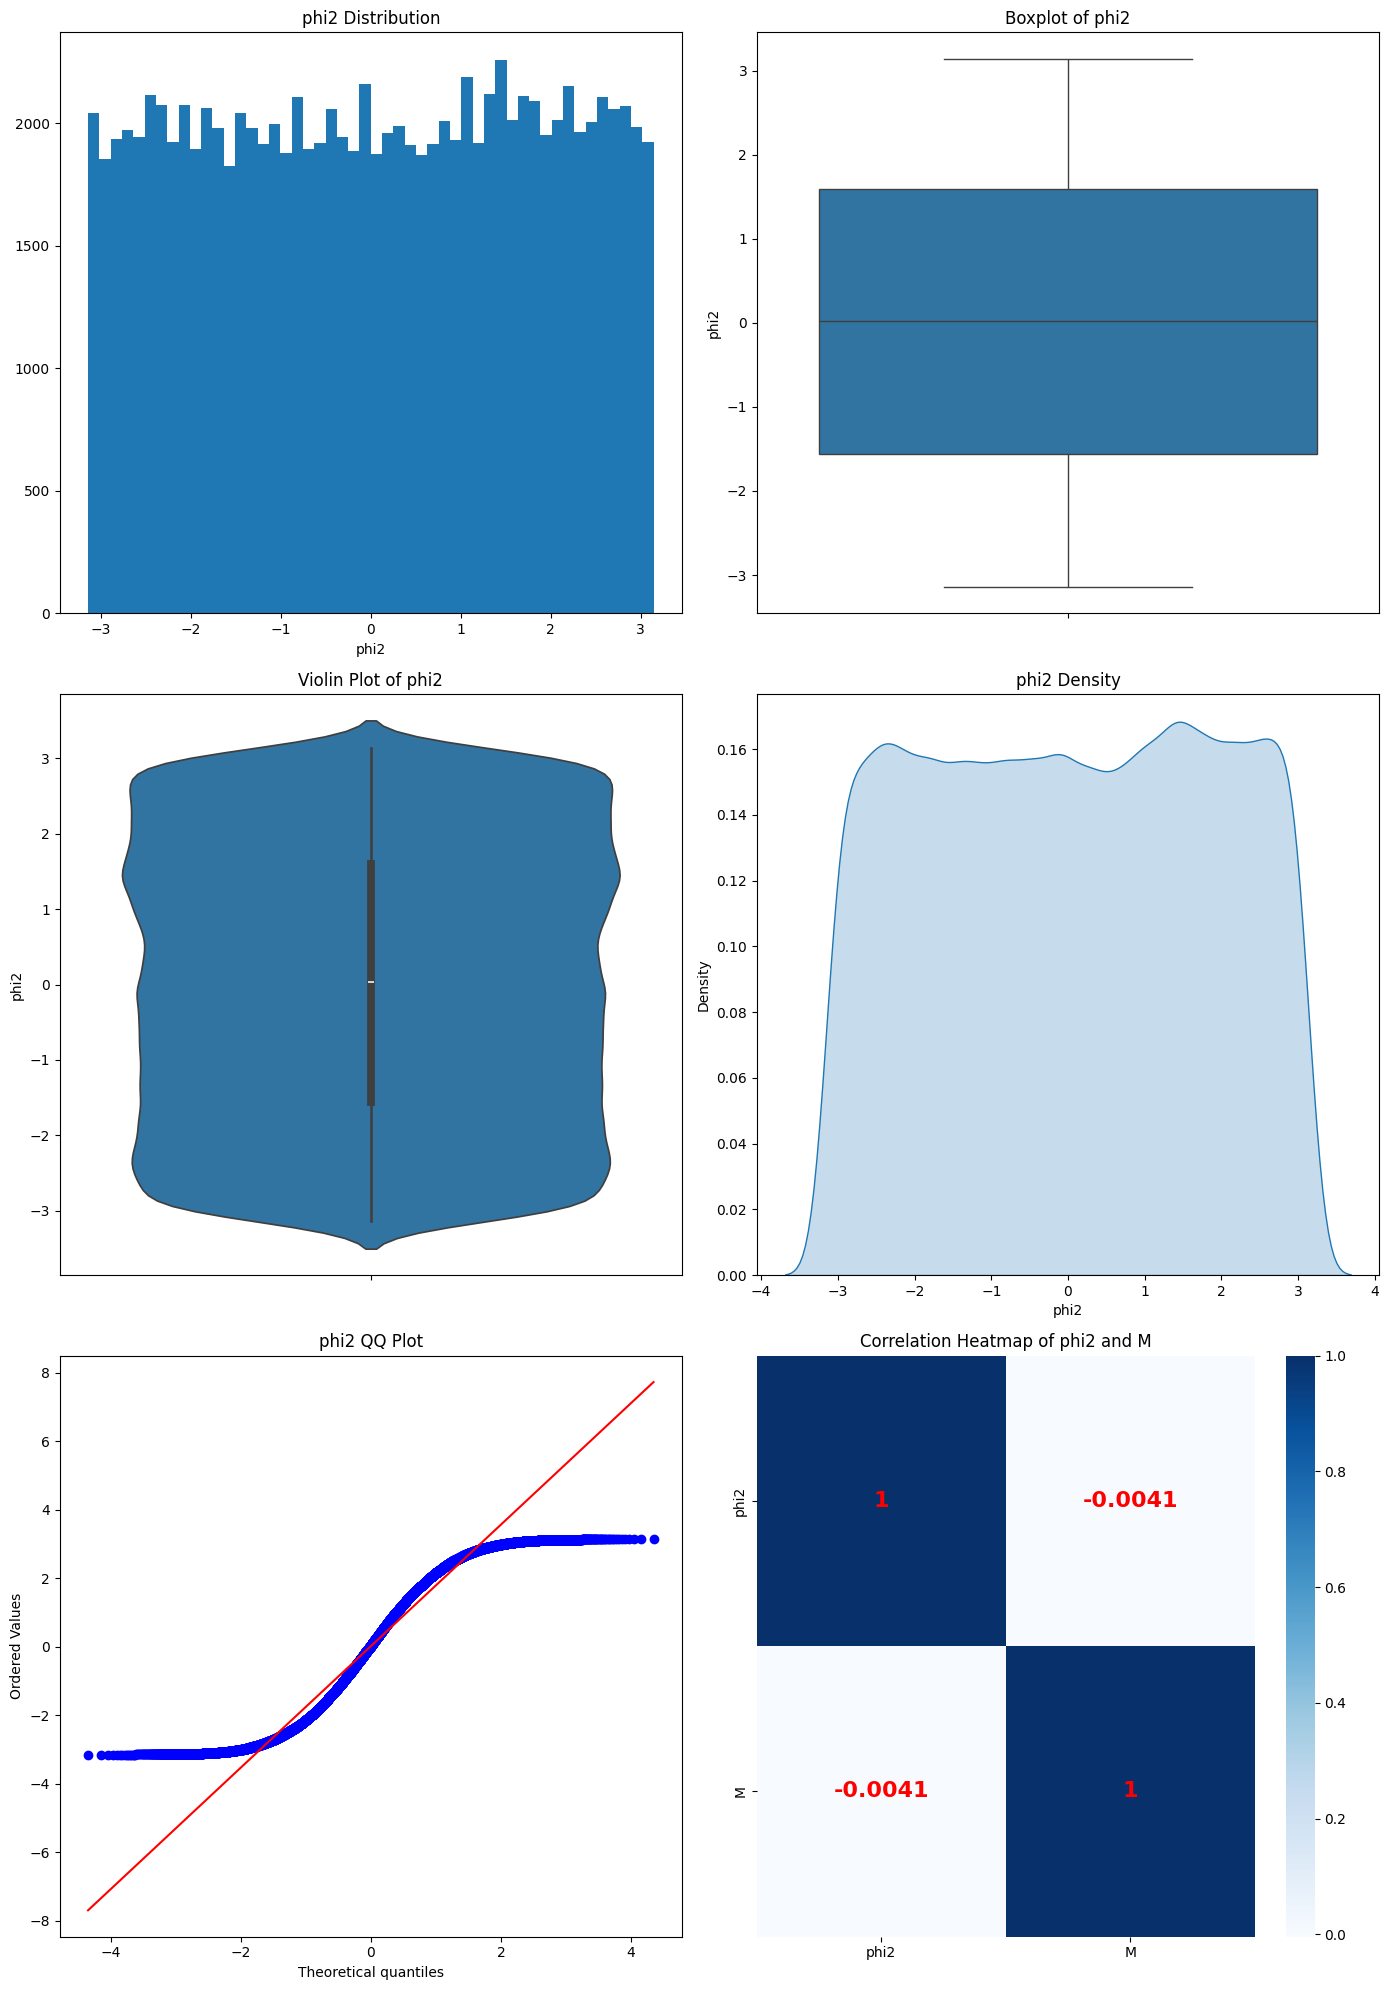

#####################################


In [ ]:
def num_summary(dataframe, numerical_col, plot=False, target_col=None):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    desc = dataframe[numerical_col].describe(quantiles)
    skewness = dataframe[numerical_col].skew()
    kurtosis = dataframe[numerical_col].kurtosis()

    print(desc)
    print(f"Skewness: {skewness:.2f}")
    print(f"Kurtosis: {kurtosis:.2f}")

    if plot:
        fig, axs = plt.subplots(3, 2, figsize=(14, 20))

        # Histogram
        axs[0, 0].hist(dataframe[numerical_col], bins=50)
        axs[0, 0].set_xlabel(numerical_col)
        axs[0, 0].set_title(numerical_col + ' Distribution')

        # Boxplot
        sns.boxplot(y=numerical_col, data=dataframe, ax=axs[0, 1])
        axs[0, 1].set_title("Boxplot of " + numerical_col)

        # Violin Plot
        sns.violinplot(y=numerical_col, data=dataframe, ax=axs[1, 0])
        axs[1, 0].set_title("Violin Plot of " + numerical_col)

        # Density Plot
        sns.kdeplot(dataframe[numerical_col], shade=True, ax=axs[1, 1])
        axs[1, 1].set_xlabel(numerical_col)
        axs[1, 1].set_title(numerical_col + ' Density')

        # QQ Plot
        stats.probplot(dataframe[numerical_col], dist="norm", plot=axs[2, 0])
        axs[2, 0].set_title(numerical_col + ' QQ Plot')

        # Correlation Heatmap
        corr = dataframe[[numerical_col, target_col]].corr()
        sns.heatmap(corr, annot=True, cmap='Blues', ax=axs[2, 1], annot_kws={"size": 16, "weight": "bold", "color":"red"})
        axs[2, 1].set_title(f'Correlation Heatmap of {numerical_col} and {target_col}')

        plt.tight_layout()
        plt.show()

    print("#####################################")



for col in num_cols[:-1]:
        num_summary(df, col, plot=True, target_col="M")

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> STATISTICAL ANALYSIS</div>

## MAIN HYPOTHESIS

### Null Hypothesis (H0):

The distribution of the measured variable (M) is the same across all groups.

### Alternative Hypothesis (H1):

At least one group's distribution of the measured variable (M) is different from the others.

In [ ]:
df.head()

,Run,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,-1,8.948
1,147115,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,-1,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893
2,147115,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388
3,147115,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,-1,3.729
4,147115,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,-1,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,-1,2.747


## Interpretation:

### Null Hypothesis (H0):

The data is normally distributed.

### Alternative Hypothesis (H1):

The data is not normally distributed.

In [ ]:
# Shapiro-Wilk test for normality (each values)
for group in list(df["Run"].unique()):
    statistic, pvalue = shapiro(df.loc[df["Run"] == group, "M"])
    print(f"Shapiro-Wilk test for {group}: statistic = {statistic:.3f}, p-value = {pvalue:.3f}")

Shapiro-Wilk test for 147115: statistic = 0.834, p-value = 0.000
Shapiro-Wilk test for 146644: statistic = 0.831, p-value = 0.000
Shapiro-Wilk test for 149181: statistic = 0.871, p-value = 0.000
Shapiro-Wilk test for 147114: statistic = 0.839, p-value = 0.000
Shapiro-Wilk test for 149011: statistic = 0.867, p-value = 0.000
Shapiro-Wilk test for 148031: statistic = 0.829, p-value = 0.000
Shapiro-Wilk test for 147754: statistic = 0.817, p-value = 0.000
Shapiro-Wilk test for 147929: statistic = 0.835, p-value = 0.000
Shapiro-Wilk test for 148029: statistic = 0.833, p-value = 0.000
Shapiro-Wilk test for 147926: statistic = 0.837, p-value = 0.000
Shapiro-Wilk test for 146944: statistic = 0.832, p-value = 0.000
Shapiro-Wilk test for 149182: statistic = 0.867, p-value = 0.000
Shapiro-Wilk test for 146511: statistic = 0.827, p-value = 0.000


### Conclusion:

The p-values for all groups are 0.000, indicating a rejection of the null hypothesis. Thus, the data does not follow a normal distribution for any of the groups.

Given that the data does not meet the assumption of normality, nonparametric tests are appropriate for comparing groups. The Kruskal-Wallis test was selected for this purpose.

In [ ]:
# Perform Kruskal-Wallis test
h_statistic, pvalue = kruskal(df.loc[df["Run"] == 146644, "M"],
                                            df.loc[df["Run"] == 146944, "M"],
                                            df.loc[df["Run"] == 147114, "M"],
                                            df.loc[df["Run"] == 147115, "M"],
                                            df.loc[df["Run"] == 147754, "M"],
                                            df.loc[df["Run"] == 147926, "M"],
                                            df.loc[df["Run"] == 147929, "M"],
                                            df.loc[df["Run"] == 148029, "M"],
                                            df.loc[df["Run"] == 148031, "M"],
                                            df.loc[df["Run"] == 149011, "M"],
                                            df.loc[df["Run"] == 149181, "M"])
print(f"Kruskal-Wallis test: H-statistic = {h_statistic:.3f}, p-value = {pvalue:.3f}")

Kruskal-Wallis test: H-statistic = 1687.115, p-value = 0.000


### Conclusion

Given the p-value is significantly less than the typical alpha level of 0.05, we reject the null hypothesis.

In [ ]:
from statsmodels.stats.multicomp import MultiComparison
comparison = MultiComparison(df['M'], df["Run"])
tukey = comparison.tukeyhsd(0.05)
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
146511 146644   -0.511 0.9987 -2.1902  1.1681  False
146511 146944  -0.5621 0.9988  -2.421  1.2967  False
146511 147114   0.1877    1.0 -1.6541  2.0296  False
146511 147115  -0.0737    1.0 -1.9312  1.7838  False
146511 147754   0.0735    1.0 -1.7375  1.8845  False
146511 147926   1.4021 0.3083 -0.3825  3.1866  False
146511 147929    0.968 0.8634 -0.8409  2.7769  False
146511 148029   0.9718 0.8625 -0.8423  2.7859  False
146511 148031   0.3843    1.0 -1.3802  2.1487  False
146511 149011   7.6386    0.0  5.9017  9.3756   True
146511 149181   8.2657    0.0  6.6363  9.8951   True
146511 149182   7.3233    0.0  5.1722  9.4744   True
146644 146944  -0.0511    1.0 -1.3639  1.2616  False
146644 147114   0.6988 0.8519 -0.5897  1.9872  False
146644 147115   0.4373 0.9968 -0.8734   1.748  False
146644 147754   0.5845 0.9428 -0.6595  1.8285 

## General Comments

### Significant Differences (Marked as True):

There are significant differences between the groups 146511 and 149011, 149181, and 149182.

Significant differences are also present between the groups 146644 and 147926, 147929, 148029, 149011, 149181, and 149182.

Significant differences exist between the groups 146944 and 147926, 147929, 148029, 149011, 149181, and 149182.

### Non-Significant Differences (Marked as False):

There are many group pairs where the difference is not statistically significant. For example, there are no significant differences between the groups 146511 and 146644, 146944, 147114, 147115, 147754, 147926, 147929, 148029, 148031.

Similarly, there are no significant differences between the groups 146944 and 147115, 147754, 148031, etc.


## Specific Examples

The mean difference between 146511 and 149011 is 7.6386 with a p-value of 0.0 (significant).

The mean difference between 146644 and 149011 is 8.1497 with a p-value of 0.0 (significant).

The mean difference between 146944 and 149181 is 8.8278 with a p-value of 0.0 (significant).


## Interpretation of Results

### Significant Differences:

These results indicate that there are notable differences between some groups. For instance, there are significant differences between the groups 146511 and 149011, 149181, and 149182. This suggests that these groups are significantly different in terms of the measured variable (M).

### Non-Significant Differences:

For many pairs, the p-adj value is 1.0 or very close to 1.0, indicating that the differences between these groups are not statistically significant.


## Conclusion

### Significant Differences:

The Tukey HSD test has shown that there are significant differences between some groups. Notably, groups such as 149011, 149181, and 149182 show significant differences when compared to other groups.

### Non-Significant Differences:

There are no significant differences between most groups. This suggests that some groups are similar in terms of the measured variable.

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> HANDLINGS WITH OUTLIERS </div>

In [ ]:
df["Q1"] = df["Q1"].map({-1 : 0 , 1: 1})
df["Q2"] = df["Q2"].map({-1 : 0 , 1: 1})
df = pd.get_dummies(df, columns=['Run'], drop_first = True)


In [ ]:
for col in df.select_dtypes(include=bool).columns:
    df[col] = df[col].astype(int)
df.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,Run_146644,Run_146944,Run_147114,Run_147115,Run_147754,Run_147926,Run_147929,Run_148029,Run_148031,Run_149011,Run_149181,Run_149182
0,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,0,8.948,0,0,0,1,0,0,0,0,0,0,0,0
1,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,0,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893,0,0,0,1,0,0,0,0,0,0,0,0
2,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388,0,0,0,1,0,0,0,0,0,0,0,0
3,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,0,3.729,0,0,0,1,0,0,0,0,0,0,0,0
4,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,0,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,0,2.747,0,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 99915
Variables: 29
cat_cols: 14
num_cols: 15
cat_but_car: 0
num_but_cat: 14


In [ ]:
num_cols

['E1',
 'px1 ',
 'py1',
 'pz1',
 'pt1',
 'eta1',
 'phi1',
 'E2',
 'px2',
 'py2',
 'pz2',
 'pt2',
 'eta2',
 'phi2',
 'M']

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.04, q3=0.96):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def replace_with_thresholds(dataframe, variable, q1=0.04, q3=0.96):
    low_limit, up_limit = outlier_thresholds(dataframe, variable, q1=0.05, q3=0.95)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [ ]:
df.head().style.set_properties(**{'background-color': 'lightyellow',
                                                    'color': 'blue','border-color': 'black',
                                                    'border-width': '1px','border-style': 'solid'})

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,Run_146644,Run_146944,Run_147114,Run_147115,Run_147754,Run_147926,Run_147929,Run_148029,Run_148031,Run_149011,Run_149181,Run_149182
0,58.714100,-7.311320,10.531000,-57.297400,12.820200,-2.202670,2.177660,1,11.283600,-1.032340,-1.880660,-11.077800,2.145370,-2.344030,-2.072810,0,8.948410,0,0,0,1,0,0,0,0,0,0,0,0
1,6.611880,-4.152130,-0.579855,-5.112780,4.192420,-1.028420,-3.002840,0,17.149200,-11.713500,5.044740,11.464700,12.753600,0.808077,2.734920,1,15.893000,0,0,0,1,0,0,0,0,0,0,0,0
2,25.541900,-11.480900,2.041680,22.724600,11.661000,1.420480,2.965600,1,15.820300,-1.472800,2.258950,-15.588800,2.696670,-2.455080,2.148570,1,38.387700,0,0,0,1,0,0,0,0,0,0,0,0
3,65.395900,7.512140,11.887100,63.866200,14.061900,2.218380,1.007210,1,25.127300,4.087860,2.596410,24.656300,4.842720,2.330210,0.565865,0,3.728620,0,0,0,1,0,0,0,0,0,0,0,0
4,61.450400,2.952840,-14.622700,-59.612100,14.917900,-2.093750,-1.371540,0,13.887100,-0.277757,-2.425600,-13.670800,2.441450,-2.423700,-1.684810,0,2.747180,0,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
for col in num_cols:
    print(col, check_outlier(df, col))
    if check_outlier(df, col):
        replace_with_thresholds(df, col)

E1 True
px1  True
py1 True
pz1 True
pt1 True
eta1 False
phi1 False
E2 True
px2 True
py2 True
pz2 True
pt2 True
eta2 False
phi2 False
M False


In [ ]:
df["Run_149182"].value_counts()

,count
Run_149182,
0,96998
1,2917


In [ ]:
df.columns = [col.upper() for col in df.columns]

df.head().style.set_properties(**{'background-color': 'lightyellow',
                                                    'color': 'blue','border-color': 'black',
                                                    'border-width': '1px','border-style': 'solid'})

,E1,PX1,PY1,PZ1,PT1,ETA1,PHI1,Q1,E2,PX2,PY2,PZ2,PT2,ETA2,PHI2,Q2,M,RUN_146644,RUN_146944,RUN_147114,RUN_147115,RUN_147754,RUN_147926,RUN_147929,RUN_148029,RUN_148031,RUN_149011,RUN_149181,RUN_149182
0,58.714100,-7.311320,10.531000,-57.297400,12.820200,-2.202670,2.177660,1,11.283600,-1.032340,-1.880660,-11.077800,2.145370,-2.344030,-2.072810,0,8.948410,0,0,0,1,0,0,0,0,0,0,0,0
1,6.611880,-4.152130,-0.579855,-5.112780,4.192420,-1.028420,-3.002840,0,17.149200,-11.713500,5.044740,11.464700,12.753600,0.808077,2.734920,1,15.893000,0,0,0,1,0,0,0,0,0,0,0,0
2,25.541900,-11.480900,2.041680,22.724600,11.661000,1.420480,2.965600,1,15.820300,-1.472800,2.258950,-15.588800,2.696670,-2.455080,2.148570,1,38.387700,0,0,0,1,0,0,0,0,0,0,0,0
3,65.395900,7.512140,11.887100,63.866200,14.061900,2.218380,1.007210,1,25.127300,4.087860,2.596410,24.656300,4.842720,2.330210,0.565865,0,3.728620,0,0,0,1,0,0,0,0,0,0,0,0
4,61.450400,2.952840,-14.622700,-59.612100,14.917900,-2.093750,-1.371540,0,13.887100,-0.277757,-2.425600,-13.670800,2.441450,-2.423700,-1.684810,0,2.747180,0,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
df[[col for col in df.columns if "RUN" in col]] = df[[col for col in df.columns if "RUN" in col]].astype("int64")

In [ ]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 99915
Variables: 29
cat_cols: 14
num_cols: 15
cat_but_car: 0
num_but_cat: 14


In [ ]:
df.dropna(inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99915 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   E1          99915 non-null  float64
 1   PX1         99915 non-null  float64
 2   PY1         99915 non-null  float64
 3   PZ1         99915 non-null  float64
 4   PT1         99915 non-null  float64
 5   ETA1        99915 non-null  float64
 6   PHI1        99915 non-null  float64
 7   Q1          99915 non-null  int64  
 8   E2          99915 non-null  float64
 9   PX2         99915 non-null  float64
 10  PY2         99915 non-null  float64
 11  PZ2         99915 non-null  float64
 12  PT2         99915 non-null  float64
 13  ETA2        99915 non-null  float64
 14  PHI2        99915 non-null  float64
 15  Q2          99915 non-null  int64  
 16  M           99915 non-null  float64
 17  RUN_146644  99915 non-null  int64  
 18  RUN_146944  99915 non-null  int64  
 19  RUN_147114  99915 non-null  in

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> FEATURE EXRACTION </div>

In [ ]:
df.head()

,E1,PX1,PY1,PZ1,PT1,ETA1,PHI1,Q1,E2,PX2,PY2,PZ2,PT2,ETA2,PHI2,Q2,M,RUN_146644,RUN_146944,RUN_147114,RUN_147115,RUN_147754,RUN_147926,RUN_147929,RUN_148029,RUN_148031,RUN_149011,RUN_149181,RUN_149182
0,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,0,8.948,0,0,0,1,0,0,0,0,0,0,0,0
1,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,0,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893,0,0,0,1,0,0,0,0,0,0,0,0
2,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388,0,0,0,1,0,0,0,0,0,0,0,0
3,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,0,3.729,0,0,0,1,0,0,0,0,0,0,0,0
4,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,0,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,0,2.747,0,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
# Calculate the magnitudes of the momenta for two particles
df['P1'] = np.sqrt(df['PX1 ']**2 + df['PY1']**2 + df['PZ1']**2)
df['P2'] = np.sqrt(df['PX2']**2 + df['PY2']**2 + df['PZ2']**2)

# Calculate the rapidity for two particles
df['Y1'] = 0.5 * np.log((df['E1'] + df['PZ1']) / (df['E1'] - df['PZ1']))
df['Y2'] = 0.5 * np.log((df['E2'] + df['PZ2']) / (df['E2'] - df['PZ2']))

# Calculate the transverse energy for two particles
df['ET1'] = df['E1'] * np.sinh(df['ETA1'])
df['ET2'] = df['E2'] * np.sinh(df['ETA2'])

# Calculate the differences in azimuthal angle and pseudorapidity
df['DELTA_PHI'] = df['PHI2'] - df['PHI1']
df['DELTA_ETA'] = df['ETA2'] - df['ETA1']

# Calculate the total transverse momentum
df['PT'] = np.sqrt(df['PT1']**2 + df['PT2']**2)

# Electron mass in GeV
m_e = 0.511

# Calculate the invariant momenta for two electrons
df['P_INV1'] = np.sqrt(df['E1']**2 - m_e**2)
df['P_INV2'] = np.sqrt(df['E2']**2 - m_e**2)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99915 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   E1          99915 non-null  float64
 1   PX1         99915 non-null  float64
 2   PY1         99915 non-null  float64
 3   PZ1         99915 non-null  float64
 4   PT1         99915 non-null  float64
 5   ETA1        99915 non-null  float64
 6   PHI1        99915 non-null  float64
 7   Q1          99915 non-null  int64  
 8   E2          99915 non-null  float64
 9   PX2         99915 non-null  float64
 10  PY2         99915 non-null  float64
 11  PZ2         99915 non-null  float64
 12  PT2         99915 non-null  float64
 13  ETA2        99915 non-null  float64
 14  PHI2        99915 non-null  float64
 15  Q2          99915 non-null  int64  
 16  M           99915 non-null  float64
 17  RUN_146644  99915 non-null  int64  
 18  RUN_146944  99915 non-null  int64  
 19  RUN_147114  99915 non-null  in

In [ ]:
df.dropna(axis = 0, inplace = True)

In [ ]:
cat_cols

['Q1',
 'Q2',
 'RUN_146644',
 'RUN_146944',
 'RUN_147114',
 'RUN_147115',
 'RUN_147754',
 'RUN_147926',
 'RUN_147929',
 'RUN_148029',
 'RUN_148031',
 'RUN_149011',
 'RUN_149181',
 'RUN_149182']

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> CORRELATION </div>

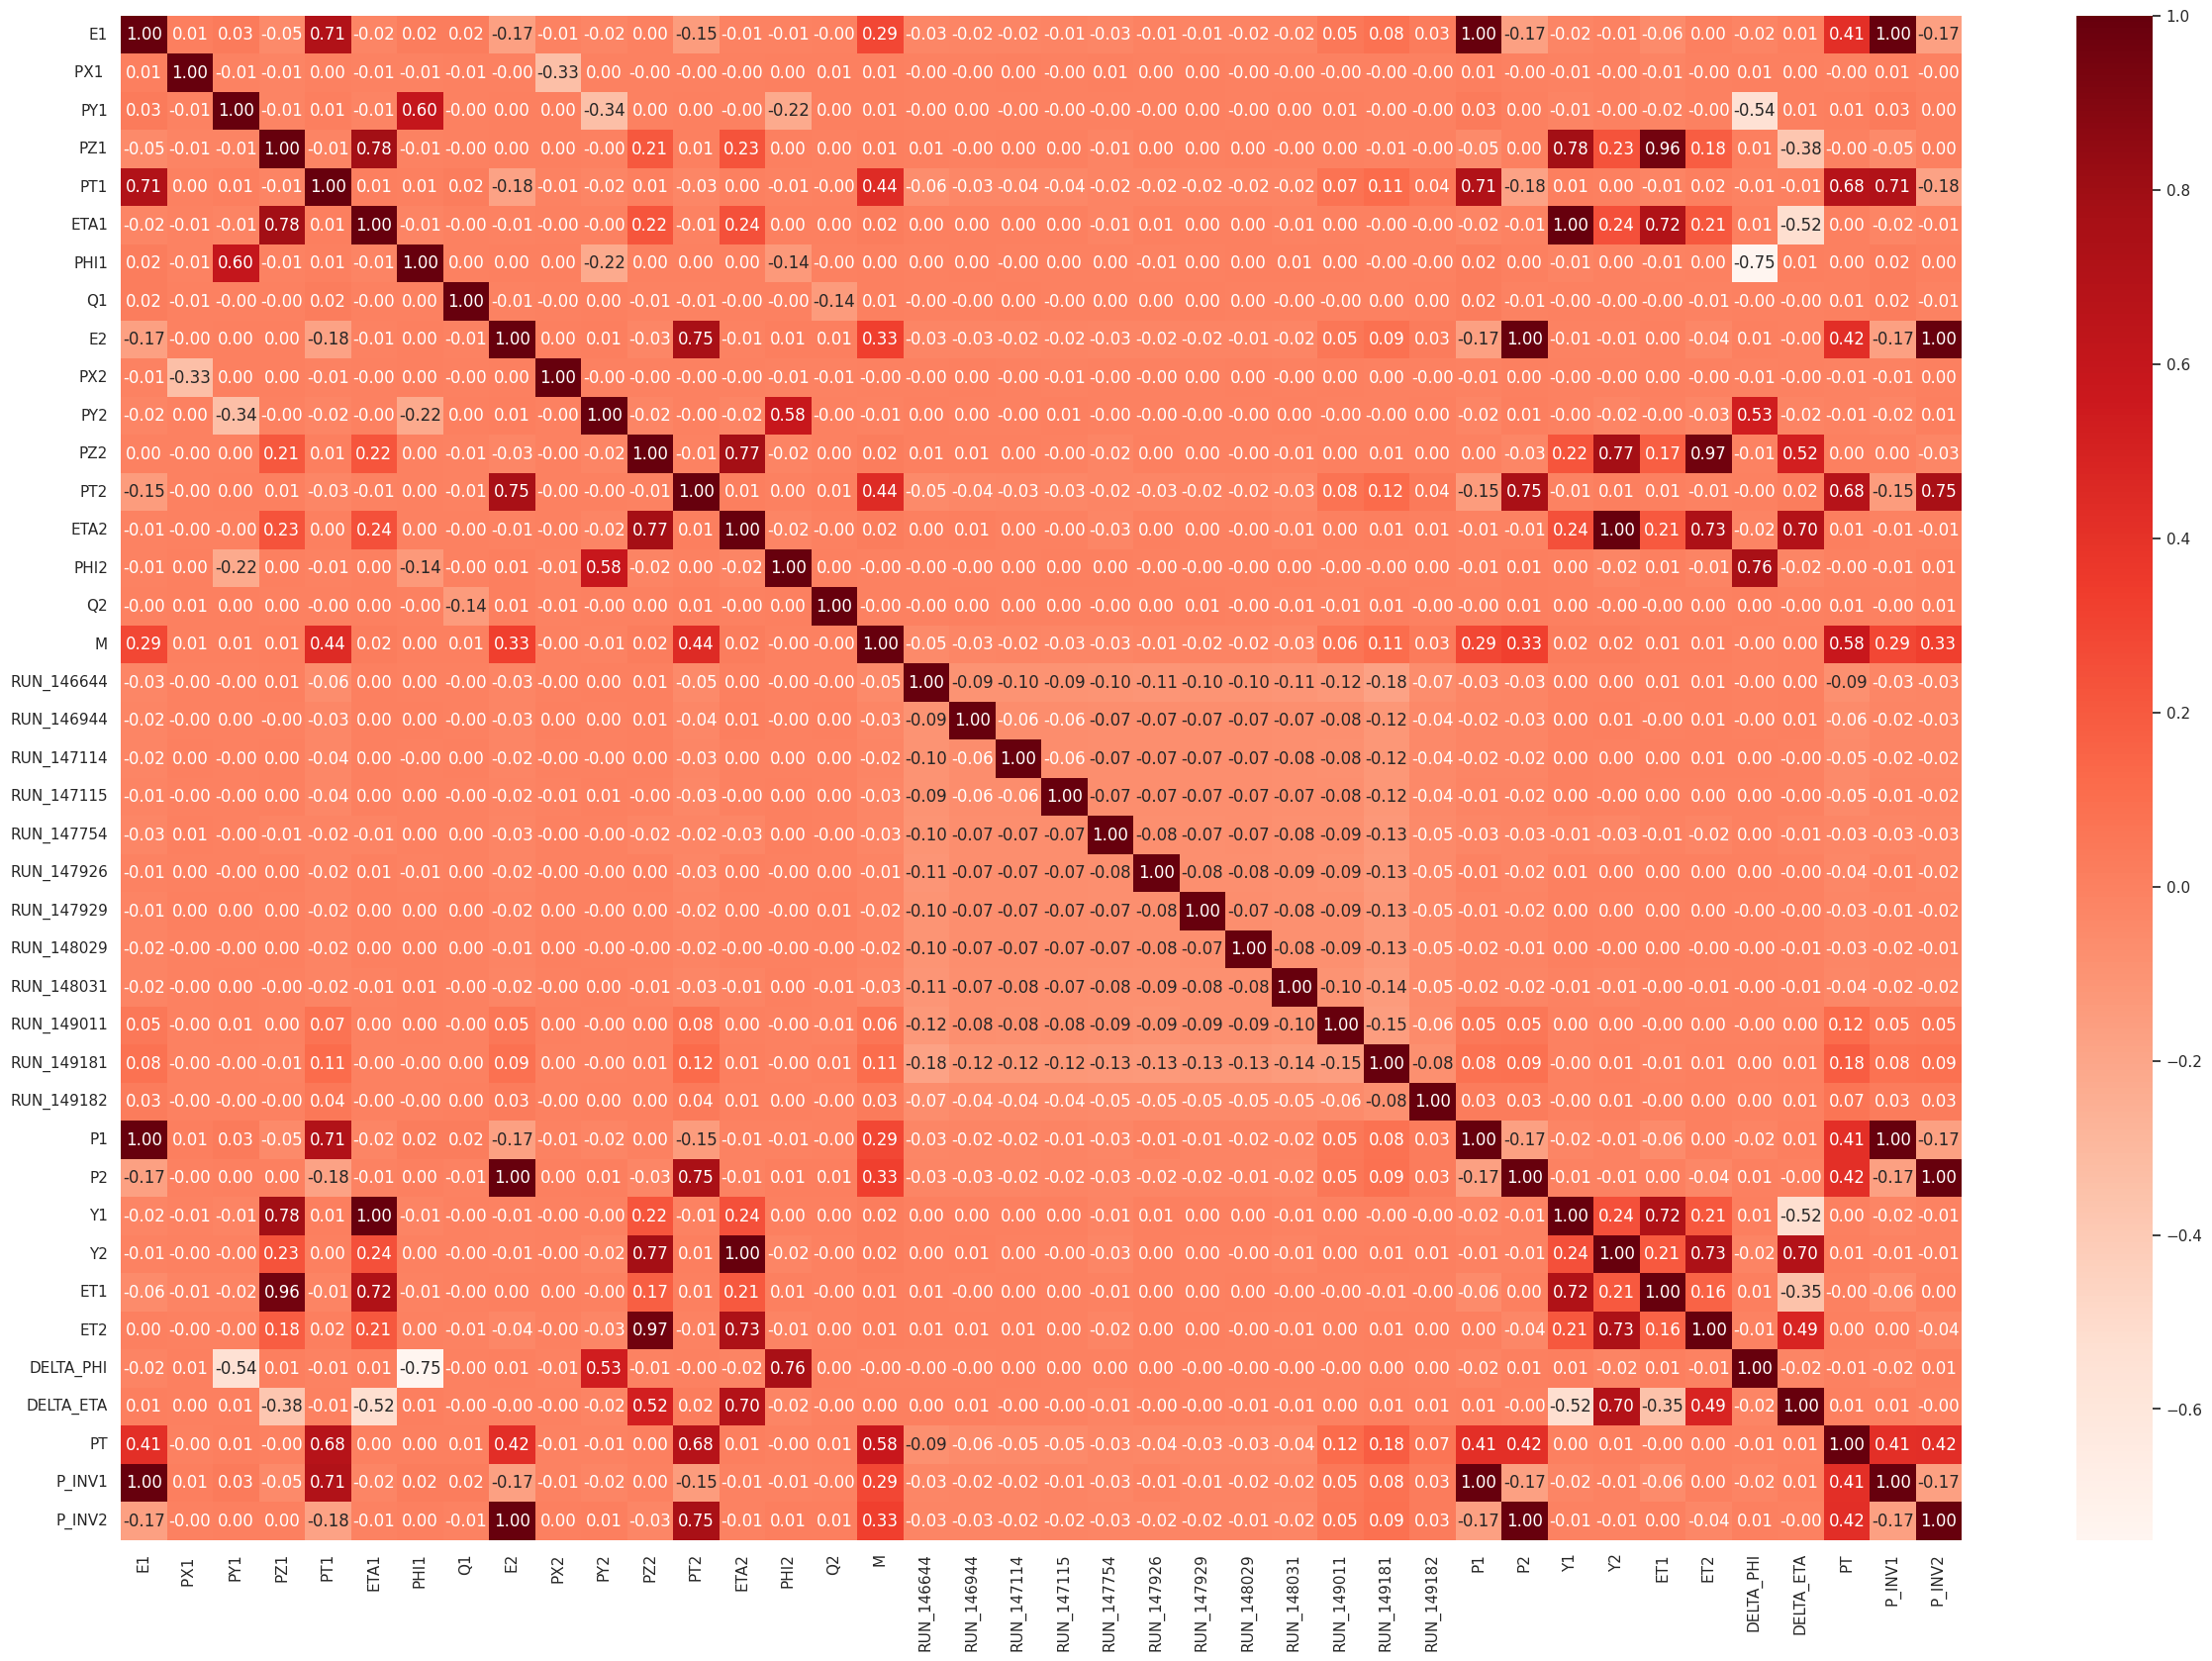

In [ ]:
corr = df.corr()
sns.set(rc={'figure.figsize': (30, 20)})
sns.heatmap(corr, cmap="Reds", annot=True, fmt=".2f")
plt.show()

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> SCALING </div>

In [ ]:
y = df["M"]
X = df.drop("M", axis=1)

In [ ]:
scaler = MinMaxScaler()
numerical_cols = X.select_dtypes(include=['float64']).columns
for col in numerical_cols:
    X[col] = scaler.fit_transform(X[[col]])

In [ ]:
X.head().style.set_properties(**{'background-color': 'lightyellow',
                                                    'color': 'blue','border-color': 'black',
                                                    'border-width': '1px','border-style': 'solid'})

,E1,PX1,PY1,PZ1,PT1,ETA1,PHI1,Q1,E2,PX2,PY2,PZ2,PT2,ETA2,PHI2,Q2,RUN_146644,RUN_146944,RUN_147114,RUN_147115,RUN_147754,RUN_147926,RUN_147929,RUN_148029,RUN_148031,RUN_149011,RUN_149181,RUN_149182,P1,P2,Y1,Y2,ET1,ET2,DELTA_PHI,DELTA_ETA,PT,P_INV1,P_INV2
0,0.200872,0.456765,0.560276,0.401089,0.132867,0.089402,0.846608,1,0.032575,0.493889,0.488498,0.483304,0.022588,0.466232,0.170109,0,0,0,0,1,0,0,0,0,0,0,0,0,0.192819,0.031177,0.189794,0.422322,0.426971,0.809377,0.160106,0.547191,0.098609,0.202056,0.033391
1,0.021034,0.475273,0.495676,0.491023,0.041666,0.310983,0.022082,0,0.050453,0.429847,0.529622,0.517720,0.135682,0.777541,0.935321,1,0,0,0,1,0,0,0,0,0,0,0,0,0.020191,0.048289,0.315569,0.756718,0.498094,0.815957,0.957130,0.721780,0.102125,0.022426,0.051266
2,0.086373,0.432337,0.510918,0.538998,0.120614,0.773090,0.972017,1,0.046403,0.491248,0.513080,0.476417,0.028465,0.455265,0.841996,1,0,0,0,1,0,0,0,0,0,0,0,0,0.082911,0.044412,0.577870,0.410542,0.514268,0.806413,0.434082,0.217567,0.090119,0.087719,0.047217
3,0.223935,0.543610,0.568161,0.609900,0.145993,0.923654,0.660320,1,0.074770,0.524588,0.515084,0.537860,0.051344,0.927870,0.590088,0,0,0,0,1,0,0,0,0,0,0,0,0,0.214958,0.071563,0.663334,0.918201,0.583404,0.826006,0.464060,0.569540,0.114059,0.225086,0.075569
4,0.210316,0.516898,0.414030,0.397100,0.155041,0.109955,0.281719,0,0.040510,0.498413,0.485263,0.479345,0.025744,0.458364,0.231864,0,0,0,0,1,0,0,0,0,0,0,0,0,0.201885,0.038772,0.201463,0.413878,0.431684,0.807636,0.474280,0.530544,0.116070,0.211487,0.041326


# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> ML MODELLING </div>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
lgm_model = LGBMRegressor(random_state=42).fit(X_train, y_train)
y_pred = lgm_model.predict(X_test)
lgm_model.score(X_test, y_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015786 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6403
[LightGBM] [Info] Number of data points in the train set: 74790, number of used features: 39
[LightGBM] [Info] Start training from score 30.006419


0.9921900982338364

In [ ]:
np.std(y_test)

25.072712058098194

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE test: %f" % (rmse))

RMSE test: 2.215767


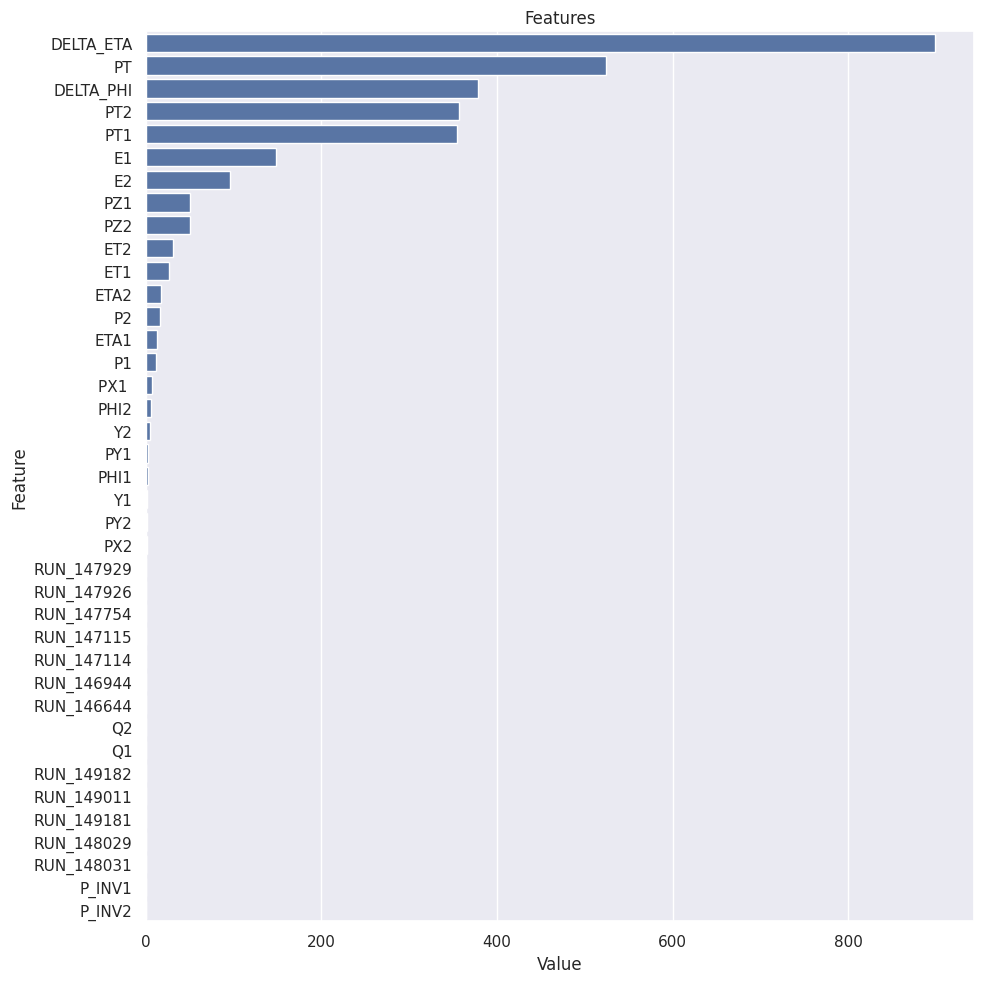

In [ ]:
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

plot_importance(lgm_model, X)

In [ ]:
models = [('LR', LinearRegression()),
          ('KNN', KNeighborsRegressor()),
          ('CART', DecisionTreeRegressor()),
          ('GBM', GradientBoostingRegressor()),
          ("XGBoost", XGBRegressor()),
          ("LightGBM", LGBMRegressor(verbose=-1)),
          ("CatBoost", CatBoostRegressor(verbose=False))]

In [ ]:
import sklearn
sklearn.metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [ ]:
errlist=[]
for name, model in models:
    err = np.mean(-cross_val_score(model, X_train, y_train, cv=3, scoring="neg_root_mean_squared_error"))
    errlist.append([name,err])
    print(f"ERROR: {round(err, 4)} ({name}) ")

ERROR: 18.0461 (LR) 
ERROR: 11.3195 (KNN) 
ERROR: 4.0632 (CART) 
ERROR: 4.7746 (GBM) 
ERROR: 2.2087 (XGBoost) 
ERROR: 2.2424 (LightGBM) 
ERROR: 1.2437 (CatBoost) 


In [ ]:
"""cat_model = CatBoostRegressor(verbose=False, random_state=42, task_type="GPU", devices='0')
cat_params = {"learning_rate": [0.01, 0.02, 0.03,0.04, 0.06, 0.08, 0.1],
               "n_estimators": [300, 400, 600, 1200, 1500],
               "depth": [3,4,5,6]}
cat_gs_best = GridSearchCV(cat_model,
                            cat_params,
                            cv=3,
                            verbose=False).fit(X_train, y_train)
cat_gs_best.best_params_
final_cat = cat_model.set_params(**cat_gs_best.best_params_).fit(X_train, y_train)
final_cat.score(X_test,y_test)
y_pred_cat = final_cat.predict(X_test)
mse = mean_squared_error(y_test, y_pred_cat)
print("Mean Squared Error:", mse)"""

In [ ]:
#cat_gs_best.best_params_

In [ ]:
best = {"learning_rate" : 0.08, "n_estimators" : 1500, "depth" : 6}

In [ ]:
cat = CatBoostRegressor(**best, verbose = False)
cat.fit(X_train, y_train)
cat.score(X_test,y_test)

np.float64(0.9982706992954482)

In [ ]:
y_pred_cat = cat.predict(X_test)
mse = mean_squared_error(y_test, y_pred_cat)
print("Mean Squared Error:", mse)

Mean Squared Error: 1.087109133897671


In [ ]:
y_pred_cat

array([ 36.45955391, 104.48133557,  20.21879078, ...,   5.7161849 ,
        10.49549915,  62.34008928])

In [ ]:
y_test_df = pd.DataFrame({'Actual_Value': y_test.values})
y_pred_df = pd.DataFrame({'Predicted_Value': y_pred_cat})
result_df = pd.concat([y_test_df, y_pred_df], axis=1)
result_df

,Actual_Value,Predicted_Value
0,34.435,36.460
1,106.420,104.481
2,19.704,20.219
3,12.385,12.373
4,35.649,34.657
...,...,...
24925,25.773,26.542
24926,32.131,31.590
24927,4.946,5.716
24928,10.991,10.495


In [ ]:
fig = px.scatter(result_df, x='Actual_Value', y='Predicted_Value', title='Actual vs Predicted Values',
                 labels={'Actual_Value': 'Actual Value', 'Predicted_Value': 'Predicted Value'},
                 trendline='ols')
fig.add_shape(type='line', x0=result_df['Actual_Value'].min(), y0=result_df['Actual_Value'].min(),
              x1=result_df['Actual_Value'].max(), y1=result_df['Actual_Value'].max(),
              line=dict(color='red', dash='dash'))
fig.show()

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> ANN </div>

In [ ]:
X_train.shape

(74790, 39)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, input_shape=(X_train.shape[1],), activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(512, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(1, activation="linear")
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse',
              metrics=[tf.keras.metrics.RootMeanSquaredError()])

early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='./model.keras',
    save_weights_only=False,
    monitor='val_mse',
    mode='auto',
    save_best_only=True)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,177 (1.17 MB)

 Trainable params: 306,177 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping, checkpoint])

Epoch 1/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 307.2943 - root_mean_squared_error: 16.9147 - val_loss: 37.9197 - val_root_mean_squared_error: 6.1488
Epoch 2/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 68.0379 - root_mean_squared_error: 8.2343 - val_loss: 22.0797 - val_root_mean_squared_error: 4.6842
Epoch 3/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 45.5852 - root_mean_squared_error: 6.7408 - val_loss: 19.7946 - val_root_mean_squared_error: 4.4315
Epoch 4/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 40.8841 - root_mean_squared_error: 6.3812 - val_loss: 15.6988 - val_root_mean_squared_error: 3.9401
Epoch 5/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 36.4155 - root_mean_squared_error: 6.0189 - val_loss: 12.4319 - val_root_mean_squared_error: 3.4982
Epoch 6/100
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 35.4549 - root_mean_squared_error: 5.9365 - val_loss: 16.6339 - val_root_mean_squared_error: 4.0517
Epoch 7/100
187

In [ ]:
plt.figure(figsize=(10, 6))

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred[:10]

In [ ]:
y_test_df = pd.DataFrame({'Actual_Value': y_test.values})
y_pred_df = pd.DataFrame({'Predicted_Value': y_pred.flatten()})
result_df = pd.concat([y_test_df, y_pred_df], axis=1)
result_df

In [ ]:
fig = px.scatter(result_df, x='Actual_Value', y='Predicted_Value', title='Actual vs Predicted Values',
                 labels={'Actual_Value': 'Actual Value', 'Predicted_Value': 'Predicted Value'},
                 trendline='ols')
fig.add_shape(type='line', x0=result_df['Actual_Value'].min(), y0=result_df['Actual_Value'].min(),
              x1=result_df['Actual_Value'].max(), y1=result_df['Actual_Value'].max(),
              line=dict(color='red', dash='dash'))
fig.show()

# <div style="border-radius:10px; border:#5E5772 solid; padding: 12px; background-color: #Q07220; font-size:100%; font-family:Comic Sans MS; font-family:Comic Sans MS; text-align:center; color:#199"> CNN </div>

In [ ]:
X_train_array = X_train.values
X_test_array = X_test.values

# Reshape the data
X_train_cnn = X_train_array.reshape((X_train_array.shape[0], X_train_array.shape[1], 1))
X_test_cnn = X_test_array.reshape((X_test_array.shape[0], X_test_array.shape[1], 1))

In [ ]:
model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10)
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)
model.summary()


In [ ]:
history = model.fit(X_train_cnn, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop, checkpoint])

In [ ]:
mse, mae = model.evaluate(X_test_cnn, y_test)
print(f"Test MSE: {mse}, Test MAE: {mae}")

In [ ]:
plt.figure(figsize=(10, 6))

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
y_pred = model.predict(X_test_cnn)
y_pred[:10]

In [ ]:
y_test_df = pd.DataFrame({'Actual_Value': y_test.values})
y_pred_df = pd.DataFrame({'Predicted_Value': y_pred.flatten()})
result_df = pd.concat([y_test_df, y_pred_df], axis=1)
result_df

In [ ]:
fig = px.scatter(result_df, x='Actual_Value', y='Predicted_Value', title='Actual vs Predicted Values',
                 labels={'Actual_Value': 'Actual Value', 'Predicted_Value': 'Predicted Value'},
                 trendline='ols')
fig.add_shape(type='line', x0=result_df['Actual_Value'].min(), y0=result_df['Actual_Value'].min(),
              x1=result_df['Actual_Value'].max(), y1=result_df['Actual_Value'].max(),
              line=dict(color='red', dash='dash'))
fig.show()